# Análisis histórico de Fórmula 1 - Rendimiento competitivo de Fernando Alonso  <br>


**Autor:** Luis Pastor Nuevo 
**Proyecto:** Capstone Data Analysis  
**Herramientas:** Python, Pandas, NumPy, Matplotlib  

---

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import style
style.use('seaborn-v0_8')

%config InlineBackend.figure_format = 'retina'
%matplotlib inline

<a id="indice"></a>
## Índice

* [1. Introducción](#section1)
* [2. Pilotos](#section2)
* [3. Carreras](#section3)
* [4. Rendimiento de Fernando Alonso](#section4)
* [5. Escuderias](#section5)
* [6. Circuitos](#section6)
* [7. Alonso vs rivales](#section7)
* [8. Alonso vs Hamilton (2007)](#section8)
* [9. Conclusiones](#section9)

---

<a id="section1"></a>
## 1. Introducción
<br>

### Descripción del proyecto

Este proyecto realiza un análisis exploratorio de datos históricos de Fórmula 1 utilizando Python y la librería *Pandas*. El objetivo principal es estudiar el rendimiento competitivo de `Fernando Alonso` a lo largo de su trayectoria en el campeonato.

A partir de un conjunto de datos que incluye información sobre pilotos, carreras y resultados, se analizan diferentes aspectos como la distribución de carreras por piloto, el número de enfrentamientos directos entre pilotos y el desempeño relativo de Alonso frente a sus rivales.

El análisis también incluye un estudio específico de la temporada 2007, en la que `Fernando Alonso` y `Lewis Hamilton` compartieron equipo en McLaren, lo que permite realizar una comparación directa de su rendimiento en igualdad de condiciones.

El objetivo final es extraer conclusiones a partir de los datos y demostrar el uso de herramientas de análisis de datos para explorar información deportiva histórica.

### Objetivo del proyecto

El objetivo de este estudio es analizar el rendimiento deportivo del piloto Fernando Alonso a lo largo de su trayectoria en Fórmula 1 utilizando datos históricos de carreras.

A través de diferentes técnicas de análisis de datos se exploran:

- estadísticas de rendimiento
- evolución competitiva
- comparación con rivales
- rendimiento según circuitos
- enfrentamientos directos entre pilotos

## Dataset

El conjunto de datos, compuesto por 14 archivos CSV relacionales, incluye información sobre carreras, pilotos, escuderías, circuitos, resultados y clasificaciones.

Los datos fueron obtenidos a través de Kaggle  [(enlace)](https://www.kaggle.com/rohanrao/formula-1-world-championship-1950-2020) y tienen como fuente original la base de datos pública Ergast Developer API. Los datos de Ergast han sido trasladados y continúan actualizándose bajo el proyecto Jolpica F1, que mantiene la compatibilidad con los endpoints de la API original [(enlace)](http://api.jolpi.ca/ergast/f1/)

Las tablas principales utilizadas en el análisis han sido:

- circuits.csv
- constructors.csv
- drivers.csv
- races.csv
- results.csv
- status.csv


### Objetivos

El objetivo principal es realizar un análisis estructurado de datos históricos mediante la integración y manipulación de múltiples tablas relacionadas.

De forma específica, se desarrolla un análisis detallado sobre la trayectoria deportiva de Fernando Alonso, evaluando métricas clave como:

- Evolución de puntos por temporada
- Resultados en carrera
- Podios y victorias
- Cambios de escudería
- Comparativa de rendimiento entre etapas

### Enfoque analítico

El proyecto se centra en el desarrollo de un flujo de trabajo analítico reproducible, abordando:

- Integración de múltiples datasets relacionales
- Limpieza y transformación de datos
- Manipulación avanzada de DataFrames con pandas
- Cálculo de métricas agregadas
- Análisis temporal
- Visualización de resultados con matplotlib

Más allá de un análisis exploratorio básico, el foco está en la extracción de insights relevantes a partir de datos históricos estructurados.

### Herramientas utilizadas

- Python
- Pandas
- NumPy
- Matplotlib
- Jupyter Notebook

### Posibles extensiones

- Análisis comparativo entre pilotos históricos
- Estudio de rendimiento por escudería
- Análisis de tendencias por década
- Modelización predictiva de resultados

<div align="right">
<a href="#indice"><font size=5><i class="fa fa-arrow-circle-up" aria-hidden="true"></i></font></a>
</div>


---

<a id="section2"></a>
## 2. Pilotos
<br>

El archivo `data/drivers.csv` contiene información identificativa básica sobre los pilotos que han participado en la competición, incluyendo variables como identificador, nombre, nacionalidad, fecha de nacimiento y otros atributos relevantes.

Dado que una parte del análisis se centrará en la trayectoria deportiva de Fernando Alonso, se realiza en primer lugar una exploración estructural de este dataset con el objetivo de comprender su composición y validar la calidad de los datos disponibles.

### Análisis inicial del dataset de pilotos

Se procede a:

- Cargar el archivo `data/drivers.csv` en un DataFrame denominado `df_drivers`.
- Visualizar las primeras filas para identificar las variables disponibles.
- Analizar la estructura del DataFrame (tipos de datos, valores nulos y dimensiones).

Este paso permite:

- Verificar la correcta lectura del dataset.
- Identificar posibles ajustes necesarios en tipos de datos.
- Evaluar la integridad de la información antes de su integración con otros datasets relacionales del proyecto.

La carga del dataset se realiza directamente, sin aplicar parámetros adicionales, con el objetivo de evaluar el estado original de los datos.

In [2]:
df_drivers = pd.read_csv('./data/drivers.csv')
df_drivers.head()

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,\N,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,\N,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [3]:
df_drivers.info()

<class 'pandas.DataFrame'>
RangeIndex: 861 entries, 0 to 860
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   driverId     861 non-null    int64
 1   driverRef    861 non-null    str  
 2   number       861 non-null    str  
 3   code         861 non-null    str  
 4   forename     861 non-null    str  
 5   surname      861 non-null    str  
 6   dob          861 non-null    str  
 7   nationality  861 non-null    str  
 8   url          861 non-null    str  
dtypes: int64(1), str(8)
memory usage: 60.7 KB




Tras la inspección inicial del DataFrame se identifican oportunidades de mejora en la tipificación de variables.

Se observa que:

- La columna `driverId` actúa como identificador único, pero inicialmente no está configurada como índice.
- La variabke `dob` ha sido interpretada como tipo `str`, cuando deberían tratarse como temporal.
- La variable `nationality` presenta un conjunto limitado de valores repetidos, por lo que resulta eficiente convertirla en tipo categórico.

En lugar de realizar transformaciones posteriores sobre el DataFrame ya cargado, se opta por redefinir correctamente los tipos de datos desde el momento de la lectura del archivo. Este enfoque mejora la eficiencia, reduce la necesidad de transformaciones adicionales y garantiza una estructura de datos coherente desde el inicio del análisis.

Para ello:

- Se vuelve a cargar el archivo `data/drivers.csv`.
- Se establece `driverId` como índice del DataFrame.
- Se especifica que los valores perdidos están representados por `'\N'`.
- Se convierte `nationality` en variable categórica.
- Se indica que la columna `dob` debe interpretarse como dato temporal mediante el parámetro `parse_dates` de `pd.read_csv()`.

Este procedimiento asegura una correcta estructuración del dataset y facilita su posterior integración con el resto de tablas relacionales del proyecto.

In [4]:
new_types ={"nationality": "category"} 
df_drivers = pd.read_csv('./data/drivers.csv', dtype=new_types, na_values='\\N', parse_dates=['dob'], index_col=0)
df_drivers.head()

,driverRef,number,code,forename,surname,dob,nationality,url
driverId,,,,,,,,
1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
4,alonso,14.0,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
5,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen


In [5]:
df_drivers.info()

<class 'pandas.DataFrame'>
Index: 861 entries, 1 to 862
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   driverRef    861 non-null    str           
 1   number       59 non-null     float64       
 2   code         104 non-null    str           
 3   forename     861 non-null    str           
 4   surname      861 non-null    str           
 5   dob          861 non-null    datetime64[us]
 6   nationality  861 non-null    category      
 7   url          861 non-null    str           
dtypes: category(1), datetime64[us](1), float64(1), str(5)
memory usage: 56.0 KB


### Identificación y extracción de información específica del piloto: Fernando Alonso.

Dado que parte del análisis se centrará en la trayectoria deportiva de Fernando Alonso, se procede a aislar su registro dentro del dataset de pilotos.

La identificación se realiza utilizando su código oficial (`ALO`), lo que permite filtrar el DataFrame y obtener exclusivamente la información correspondiente a este piloto.

El resultado de esta selección es una única fila del DataFrame original. Para facilitar su manipulación posterior y permitir un acceso más directo a sus atributos individuales, se transforma esta fila en una estructura tipo `Series`, almacenándola en la variable `alonso_data`.

Adicionalmente, se extrae y almacena su identificador único (`driverId`) en la variable `alonso_id`, lo que permitirá utilizarlo como clave relacional en la integración con otros datasets del proyecto (resultados de carrera, clasificaciones, puntos, etc.).

Este paso resulta fundamental para garantizar consistencia en los cruces de información y asegurar que todos los análisis posteriores asociados al piloto se basen en su identificador único dentro del modelo de datos.




In [6]:
alonso_data = df_drivers[df_drivers['code']=='ALO'].squeeze()
alonso_id = alonso_data.name

### Análisis de edad de los pilotos

Con el objetivo de explorar la distribución generacional de los pilotos registrados en el dataset, se realiza un análisis orientado a identificar a los cinco pilotos más jóvenes.

Para ello, se utiliza la variable `dob` (fecha de nacimiento), previamente tipificada como dato temporal, lo que permite realizar ordenaciones cronológicas precisas.

El procedimiento consiste en ordenar el DataFrame en función de la fecha de nacimiento, priorizando las fechas más recientes, y seleccionar las cinco primeras observaciones resultantes.

Este tipo de análisis permite:

- Comprender la incorporación de nuevas generaciones a la competición.
- Evaluar tendencias demográficas dentro del conjunto histórico de pilotos.
- Validar la consistencia del campo temporal utilizado en análisis posteriores.

La identificación de valores extremos dentro de una variable constituye una técnica básica pero fundamental en análisis exploratorio de datos.

In [7]:
df_drivers.nlargest(5, 'dob')

,driverRef,number,code,forename,surname,dob,nationality,url
driverId,,,,,,,,
860,bearman,38.0,BEA,Oliver,Bearman,2005-05-08,British,http://en.wikipedia.org/wiki/Oliver_Bearman
861,colapinto,43.0,COL,Franco,Colapinto,2003-05-27,Argentinian,http://en.wikipedia.org/wiki/Franco_Colapinto
862,doohan,61.0,DOO,Jack,Doohan,2003-01-20,Australian,http://en.wikipedia.org/wiki/Jack_Doohan
859,lawson,30.0,LAW,Liam,Lawson,2002-02-11,New Zealander,http://en.wikipedia.org/wiki/Liam_Lawson
857,piastri,81.0,PIA,Oscar,Piastri,2001-04-06,Australian,http://en.wikipedia.org/wiki/Oscar_Piastri


### Distribución de pilotos por nacionalidad

Con el objetivo de analizar la representación internacional dentro de la competición, se estudia la distribución de pilotos por nacionalidad registrada en el dataset.

Este análisis permite identificar qué países han tenido mayor presencia histórica en Fórmula 1 y detectar posibles concentraciones geográficas en el acceso a la competición.

### Enfoque metodológico

Para ello:

- Se calcula la frecuencia de aparición de cada nacionalidad en el DataFrame `df_drivers`.
- Se seleccionan las 20 nacionalidades con mayor número de pilotos.
- Se construye una visualización mediante gráfico de barras para facilitar la comparación relativa entre países.

Dado que el número total de nacionalidades es elevado, limitar el análisis a las más representadas mejora la legibilidad y permite centrar la atención en los patrones dominantes.

Se ajustan las etiquetas del eje X para garantizar claridad visual y evitar solapamientos, mejorando así la interpretación del gráfico.

### Interpretación

Esta visualización permite:

- Identificar los países históricamente más representados en la competición.
- Detectar posibles desequilibrios geográficos.
- Comprender la evolución internacional del campeonato desde una perspectiva demográfica.

El análisis de frecuencias categóricas constituye una técnica fundamental en análisis exploratorio de datos, especialmente cuando se trabaja con variables nominales de alta cardinalidad.

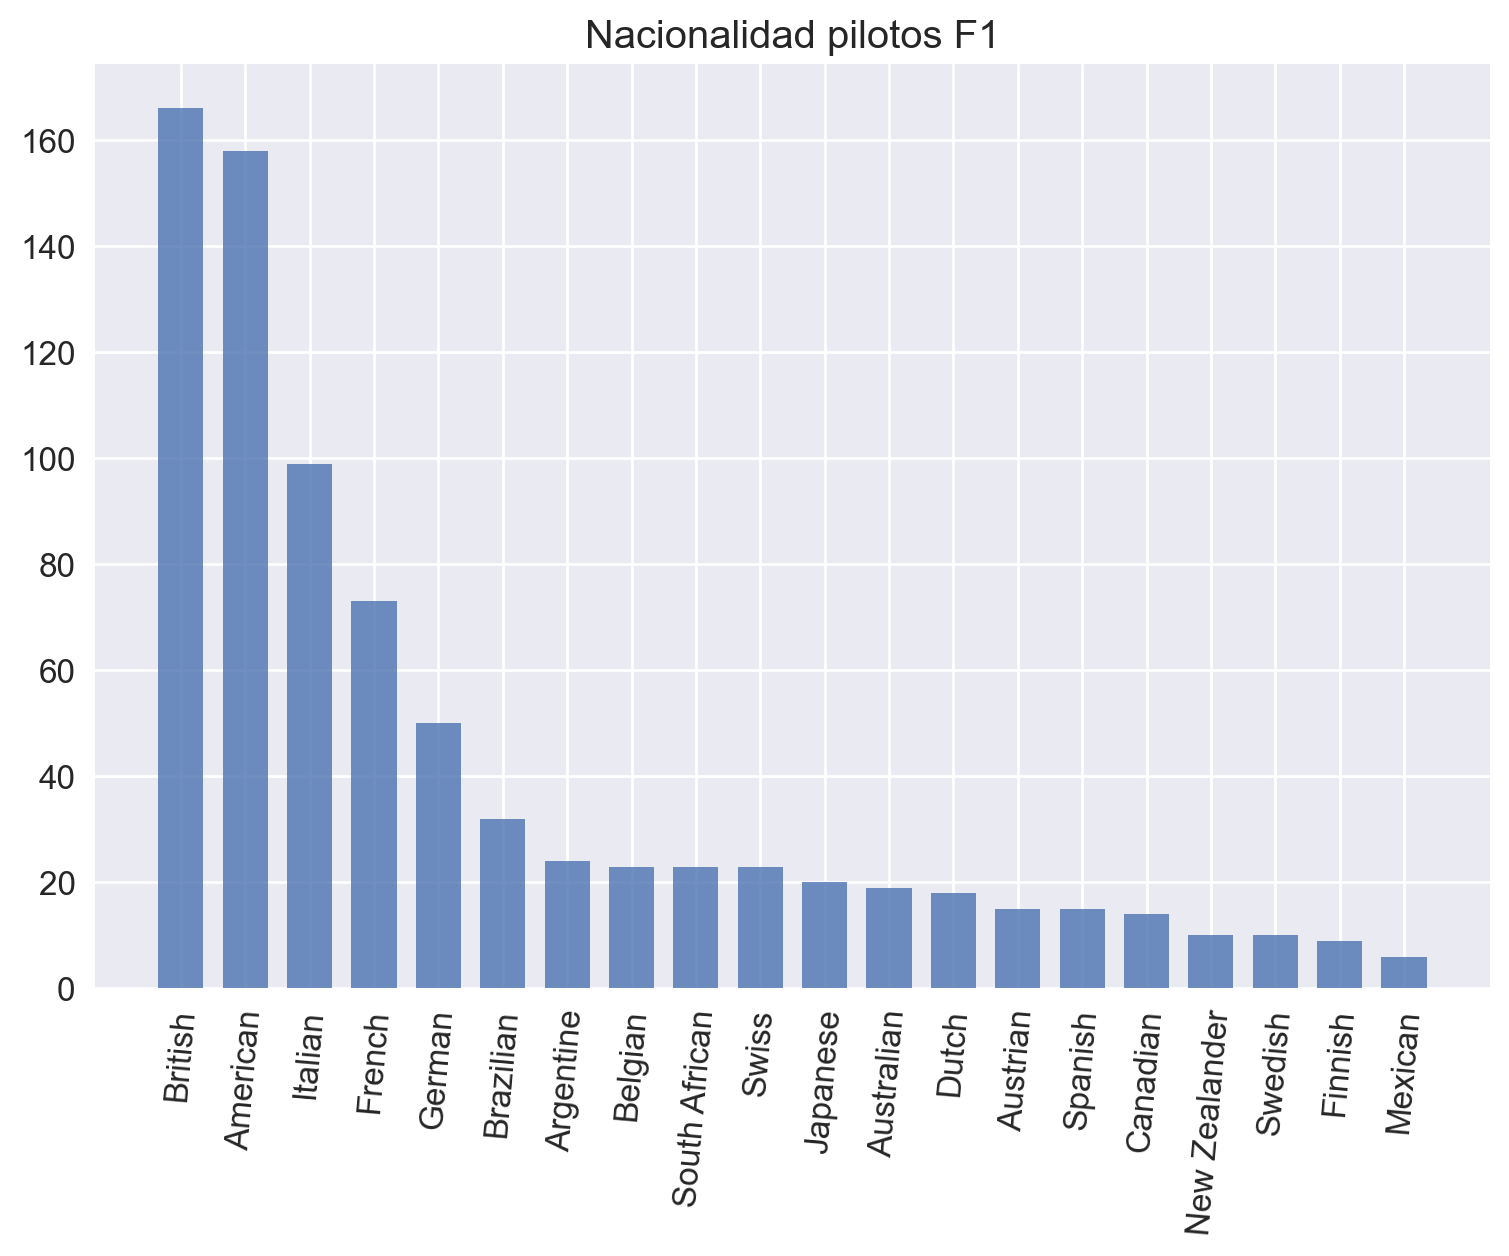

In [8]:
# Primero se agrupan los pilotos por nacinalidades, guardando los 20 países con mayor númnero de pilotos.
nacionalidades = df_drivers.groupby('nationality').size().nlargest(20)

# Se crea la figura, asignándola un tamaño determinado.
plt.figure(figsize=(9,6))

# Se dibuja el gráfico de barras, estableciendo la anchura a 0.7, con una transparencia de 0.8. Se utiliza un color predefinido.
plt.bar(nacionalidades.index, nacionalidades.values, 0.7, alpha=0.8)

# Se giran las etiquetas del eje x a 85, se centra el texto en las barras y se cambia el tamaño de la fuente
plt.xticks(range(len(nacionalidades)), nacionalidades.index, rotation=85, ha="center", fontsize='large')

# El tamaño de la fuente del eje y se deja igual que el del eje x
plt.yticks(fontsize="large")

# Se inseerta un título con un tamaño de letra superior al de los ejes x e y
plt.title('Nacionalidad pilotos F1', fontsize='x-large');

In [9]:
df_results = pd.read_csv('./data/results.csv', na_values='\\N', index_col=0)
df_results.head()

,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
resultId,,,,,,,,,,,,,,,,,
1,18,1,1,22.0,1,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1
2,18,2,2,3.0,5,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1
3,18,3,3,7.0,7,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1
4,18,4,4,5.0,11,4.0,4,4,5.0,58,+17.181,5707797.0,58.0,7.0,1:28.603,215.464,1
5,18,5,1,23.0,3,5.0,5,5,4.0,58,+18.014,5708630.0,43.0,1.0,1:27.418,218.385,1


### Distribución del número de carreras por piloto

Se dibuja un histograma con el número de carreras por piloto, utilizando 100 intervalos

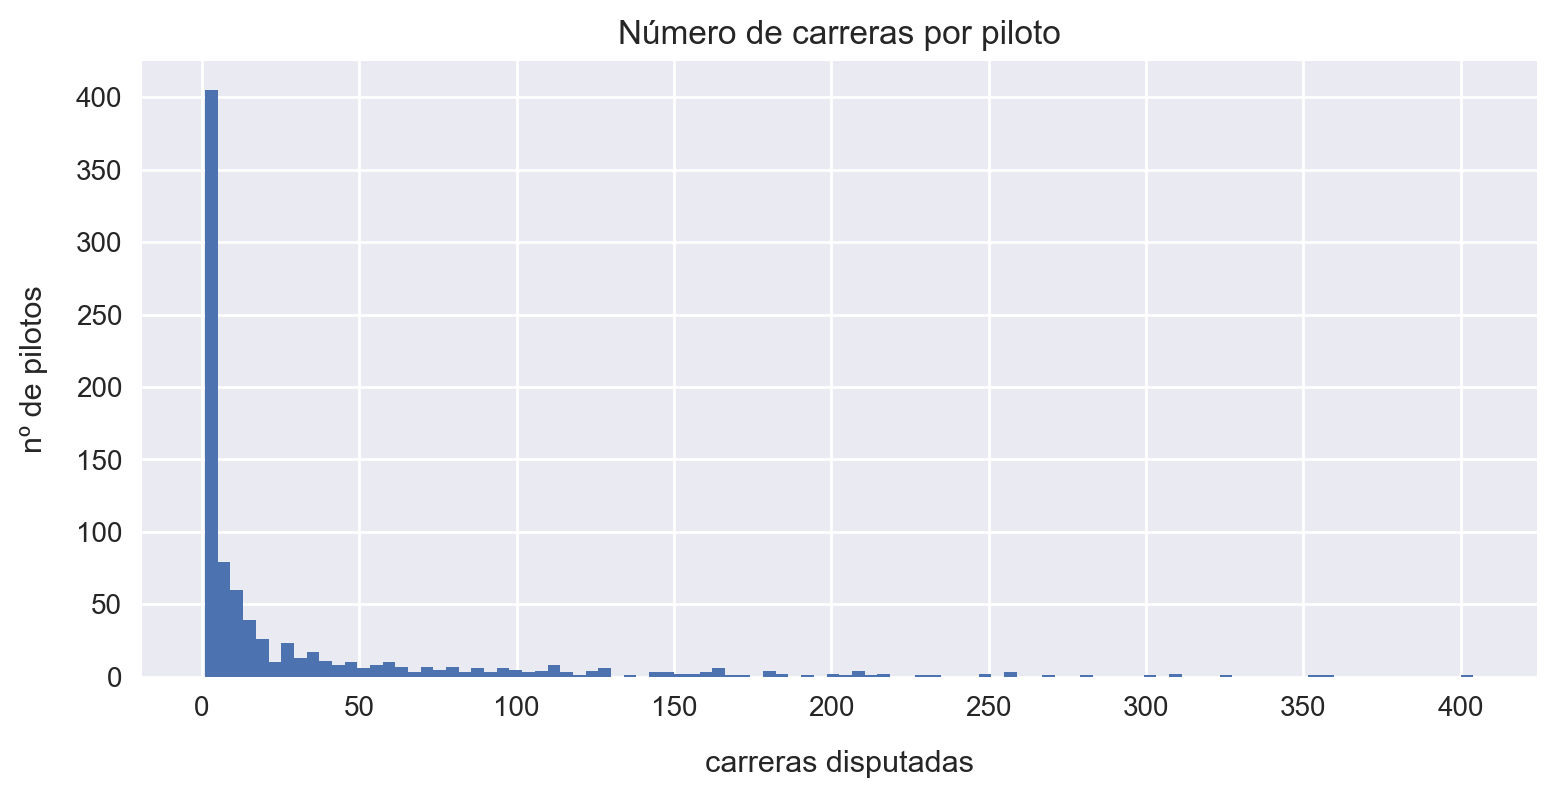

In [10]:
# Se extrae el número de carreras en las que ha participado cada uno de los pilotos.
s_carreras = df_results['driverId'].value_counts()

# Se crea una figura.
plt.figure(figsize=(9,4))

# Divide el rango de los datos en 100 bins de igual anchura y dibuja el histograma.
plt.hist(s_carreras, bins=100, density=0)

plt.title('Número de carreras por piloto')

# Se establece una separación entre los labels y los ejes x e y.
plt.xlabel('carreras disputadas', labelpad=10)
plt.ylabel('nº de pilotos',labelpad=10);

El histograma muestra la distribución del número de carreras disputadas por cada piloto presente en el conjunto de datos, utilizando 100 intervalos para visualizar con mayor detalle la densidad de observaciones.

Se observa una **distribución fuertemente sesgada hacia la derecha**. La gran mayoría de los pilotos ha participado en **muy pocas carreras**, concentrándose en los primeros intervalos del histograma. Esto refleja que muchos pilotos han tenido participaciones puntuales o carreras muy cortas en la competición.

Por otro lado, existe un **grupo reducido de pilotos con trayectorias muy largas**, que acumulan un número muy elevado de carreras. Estos casos aparecen en la cola derecha de la distribución y corresponden a pilotos que han competido durante numerosas temporadas.

En conclusión, el histograma pone de manifiesto una **estructura típica de “larga cola”**, donde pocos pilotos concentran gran parte de las participaciones totales, mientras que la mayoría tiene una presencia mucho más limitada en la competición.


<div align="right">
<a href="#indice"><font size=5><i class="fa fa-arrow-circle-up" aria-hidden="true"></i></font></a>
</div>

---

<a id="section3"></a>
## 3. Carreras
<br>


El archivo `data/races.csv` contiene información descriptiva de cada Gran Premio disputado dentro del campeonato, incluyendo variables relacionadas con la localización, la temporada y la fecha de celebración de cada carrera.

Este dataset permite complementar la información de resultados individuales con el contexto temporal y geográfico de cada evento competitivo, facilitando el desarrollo de análisis longitudinales y estudios evolutivos del campeonato.

### Carga y estructuración del dataset de carreras

Se procede a cargar el archivo en el DataFrame `df_races`, utilizando `raceId` como índice único del registro, lo que favorece la integración relacional con otros conjuntos de datos del proyecto.

Adicionalmente, se especifica que la variable `date` debe interpretarse como dato temporal mediante el parámetro `parse_dates` de `pd.read_csv()`. Esta tipificación permite realizar análisis cronológicos precisos y operaciones basadas en tiempo dentro del flujo analítico del proyecto.

In [11]:
df_races = pd.read_csv('./data/races.csv', na_values='\\N', parse_dates=['date'], index_col=0)
df_races.head()

,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
raceId,,,,,,,,,,,,,,,,,
1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Conversión de la variable temporal `time`

Se analiza la columna `time` del dataset de carreras con el objetivo de convertir su contenido al formato `DateTime` utilizando la función `pd.to_datetime()`.

In [12]:
serie_time = pd.to_datetime(df_races['time'], format='%H:%M:%S')
serie_time

raceId
1      1900-01-01 06:00:00
2      1900-01-01 09:00:00
3      1900-01-01 07:00:00
4      1900-01-01 12:00:00
5      1900-01-01 12:00:00
               ...        
1140   1900-01-01 20:00:00
1141   1900-01-01 17:00:00
1142   1900-01-01 06:00:00
1143   1900-01-01 17:00:00
1144   1900-01-01 13:00:00
Name: time, Length: 1125, dtype: datetime64[us]

### Interpretación del resultado

La columna `time` contiene información únicamente horaria, sin asociar explícitamente una fecha de referencia. Por este motivo, al realizar la conversión a formato `DateTime` puede aparecer una fecha base artificial (`1900-01-01`), ya que el parser necesita un componente temporal completo para construir el objeto resultante.

En este contexto, la variable no debe interpretarse como una marca temporal histórica completa, sino como un atributo descriptivo asociado al horario de inicio o desarrollo del evento.

Para análisis cronológicos rigurosos, esta variable debería combinarse con la fecha de la carrera almacenada en el dataset `df_races`, construyendo una marca temporal compuesta que permita estudiar la evolución histórica de los eventos de manera precisa.

### Construcción de la marca temporal completa de cada carrera

Con el objetivo de disponer de una variable temporal que represente de forma precisa el momento de celebración de cada Gran Premio, se crea una nueva columna denominada `datetime`.

Esta variable combina la fecha de la carrera almacenada en `df_races['date']` con el componente horario contenido en `df_races['time']`.

Para ello, se procede a convertir la columna `time` a formato `Timedelta` mediante la función `pd.to_timedelta()`, lo que permite tratar el valor horario como un desplazamiento temporal respecto a la fecha base.

Posteriormente, se suma este desplazamiento temporal a la fecha de la carrera, obteniendo así una marca temporal completa que integra fecha y hora del evento deportivo.

Esta transformación facilita el desarrollo de análisis cronológicos más precisos, permitiendo estudiar la evolución temporal de las carreras y realizar operaciones basadas en series temporales dentro del flujo analítico del proyecto.

In [13]:
df_races['date time'] = df_races['date'] + pd.to_timedelta(df_races['time'])
df_races.head()

,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time,date time
raceId,,,,,,,,,,,,,,,,,,
1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-03-29 06:00:00
2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-04-05 09:00:00
3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-04-19 07:00:00
4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-04-26 12:00:00
5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2009-05-10 12:00:00


### Limpieza y reorganización de variables temporales

Una vez construida la variable `datetime`, que representa la marca temporal completa de cada carrera, las columnas originales `date` y `time` dejan de ser necesarias dentro del DataFrame, ya que su información ha sido integrada en un único atributo temporal.

Con el objetivo de mantener una estructura de datos limpia y coherente, se eliminan dichas columnas y se reorganiza el DataFrame para situar la nueva variable `datetime` en la posición originalmente ocupada por `date`.

Este tipo de operación contribuye a mejorar la calidad del conjunto de datos, reduciendo redundancia de información y favoreciendo un diseño más eficiente del esquema analítico.

In [14]:
df_races = df_races[['year','round','circuitId','name','date time','url']]
df_races.head()

,year,round,circuitId,name,date time,url
raceId,,,,,,
1,2009,1,1,Australian Grand Prix,2009-03-29 06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...
2,2009,2,2,Malaysian Grand Prix,2009-04-05 09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...
3,2009,3,17,Chinese Grand Prix,2009-04-19 07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...
4,2009,4,3,Bahrain Grand Prix,2009-04-26 12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...
5,2009,5,4,Spanish Grand Prix,2009-05-10 12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...


### Distribución temporal de las carreras

Con el objetivo de analizar patrones estacionales y horarios dentro del calendario histórico de Fórmula 1, se estudia la distribución de carreras en función del mes y de la hora de celebración.

Este análisis permite identificar posibles concentraciones temporales en la organización del campeonato, así como tendencias relacionadas con la planificación del calendario deportivo.

### Enfoque metodológico

A partir de la variable `datetime`, previamente construida, se extraen:

- El mes de celebración de cada carrera.
- La hora de inicio correspondiente.

Se calculan las frecuencias agregadas para ambas dimensiones temporales, generando dos series intermedias:

- `races_month`: número de carreras por mes.
- `races_hour`: número de carreras por hora del día.

Posteriormente, se construye una figura compuesta por dos gráficos de barras:

- El gráfico izquierdo representa la distribución mensual.
- El gráfico derecho muestra la distribución horaria.

Ambas visualizaciones comparten la misma escala en el eje *y*, lo que permite realizar comparaciones visuales coherentes entre las magnitudes representadas.

### Interpretación

Este tipo de análisis permite:

- Detectar meses con mayor concentración histórica de eventos.
- Identificar franjas horarias predominantes en la celebración de carreras.
- Evaluar posibles patrones logísticos o estratégicos en la planificación del campeonato.

La exploración de dimensiones temporales constituye una práctica fundamental en análisis de datos históricos, especialmente cuando se trabaja con series de larga duración.

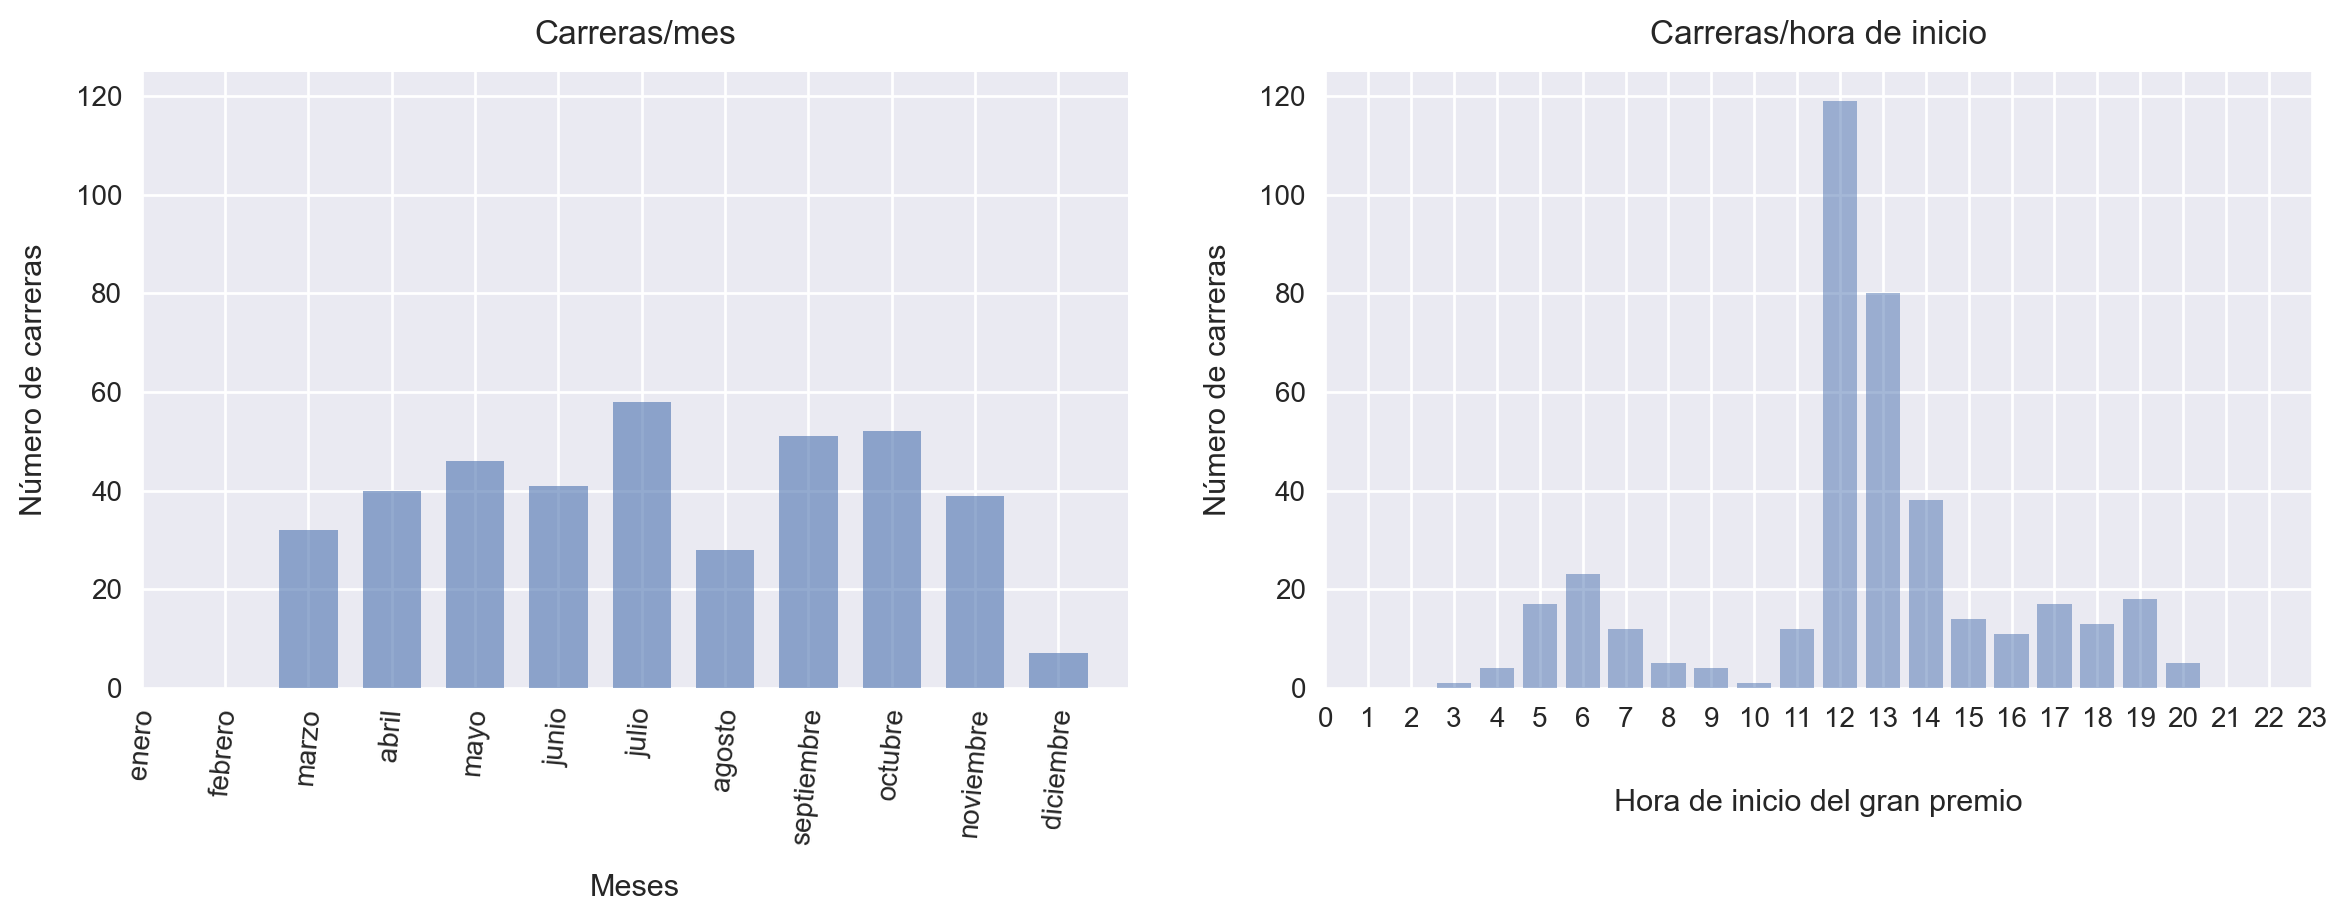

In [15]:
# Se obtienen las series con el número de carreras que se han disputado en cada mes y en cada franja horaria.
races_month = df_races['date time'].dt.month.value_counts()
races_hour = df_races['date time'].dt.hour.value_counts()

meses = {1:'enero', 2:'febrero',3:'marzo',4:'abril', 5:'mayo', 6:'junio',
         7:'julio', 8:'agosto', 9:'septiembre', 10:'octubre', 11:'noviembre', 12:'diciembre'}

# Se crea la figura.
f = plt.figure(figsize = (14,4))

#Figura de la izquierda
ax_izq = plt.subplot(1,2,1)
ax_izq.set_title('Carreras/mes', pad=10);
plt.bar(races_month.index, races_month.values, 0.7, alpha=0.6)
plt.xticks(range(1,13), meses.values(), rotation=85, ha="center", fontsize='medium');
plt.xlabel('Meses', labelpad=10)
plt.ylabel('Número de carreras', labelpad=10)

#Figura de la derecha, comparte el eje y con la figura de la izquierda
ax_der = plt.subplot(1,2,2, sharey=ax_izq)
ax_der.set_title('Carreras/hora de inicio', pad=10)
plt.bar(races_hour.index, races_hour.values, 0.8, alpha=0.5)
plt.xticks(range(24), rotation=0, ha="center", fontsize='medium')
plt.xlabel('Hora de inicio del gran premio', labelpad=20)
plt.ylabel('Número de carreras', labelpad=10);

---

### Integración del estado final de carrera

El DataFrame `df_results` incluye la variable `statusId`, un código numérico que indica el estado en el que cada piloto finalizó la carrera (finalización, abandono, accidente, fallo mecánico, etc.).

Sin embargo, este identificador carece de significado analítico directo si no se vincula con su descripción correspondiente.

Para enriquecer el análisis, se incorpora el dataset `data/status.csv`, que contiene la correspondencia entre cada `statusId` y su descripción textual.

### Carga del dataset de estados

Se procede a leer el archivo y almacenarlo en el DataFrame `df_status`, con el objetivo de:

- Facilitar la interpretación de los resultados.
- Permitir análisis agregados por tipo de finalización.
- Identificar patrones de abandono o incidencias mecánicas.

Esta integración resulta clave para transformar un identificador numérico en una variable categórica interpretable dentro del modelo de datos relacional del proyecto.

In [16]:
df_status = pd.read_csv('./data/status.csv')
df_status.head()

,statusId,status
0,1,Finished
1,2,Disqualified
2,3,Accident
3,4,Collision
4,5,Engine


### Análisis de causas de abandono en carrera

Con el objetivo de comprender los factores que históricamente han impedido a los pilotos finalizar una carrera, se analiza la distribución de los estados de terminación distintos de la finalización normal.

Para ello, se integran los DataFrames `df_results` y `df_status`, lo que permite traducir los códigos numéricos (`statusId`) en descripciones interpretables.

### Enfoque metodológico

El análisis se desarrolla en los siguientes pasos:

- Se excluye el estado que representa la finalización correcta de la carrera.
- Se calcula la frecuencia de aparición de cada estado de abandono dentro de `df_results`.
- Se seleccionan las 10 causas más frecuentes.
- Se recuperan sus descripciones desde el DataFrame `df_status`.
- Se construye un diagrama de sectores con tamaño de figura 6×6 para visualizar la distribución relativa de estas causas.

La representación mediante gráfico circular permite identificar el peso relativo de cada tipo de incidencia dentro del conjunto total de abandonos.

### Interpretación

El análisis revela qué factores han tenido mayor impacto histórico en la no finalización de carreras, distinguiendo entre causas mecánicas, incidentes en pista u otros motivos técnicos.

Este tipo de exploración aporta contexto al rendimiento de los pilotos, ya que no todos los abandonos están necesariamente relacionados con desempeño deportivo, sino con factores externos como fiabilidad mecánica o condiciones de carrera.

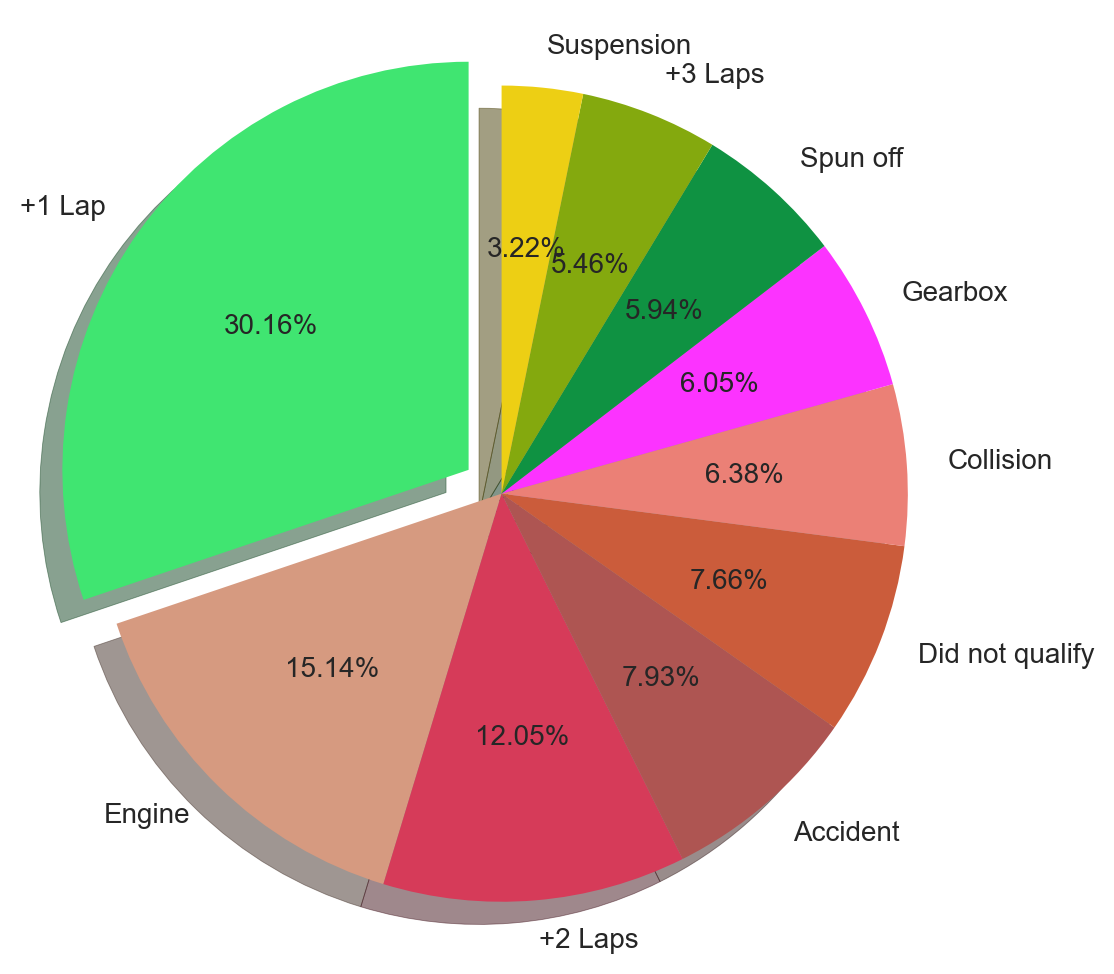

In [17]:
# Se fusionan los dos Dataframes
df_results_status = pd.merge(df_results, df_status)

# Se obtiene una serie con las 10 causas más repetidas que han impedido que un piloto acabe la carrera
abandonos = df_results_status['status'].value_counts().drop('Finished').nlargest(10)

# Se defienen los colores (en formato hexadecimal) para el gráfico
colors = ["#40E571", "#D69A80", "#D63B59", "#AE5552", "#CB5C3B", "#EB8076", "#FC33FF", "#0F9242", "#84A90E", "#EDCF14"]

# Se resalta la 1 porción, que será la principal causa que ha impedido a los pilotos terminar las carreras
explode = [0.1, 0, 0, 0, 0, 0, 0, 0, 0, 0]

# Se crea una figura de tamaño 6x6
plt.figure(figsize=(6,6))

# Se crea la gráfica
plt.pie(abandonos, labels=abandonos.index, autopct='%2.2f%%', startangle=90, explode=explode, colors=colors, shadow=True);

# Determina si se dibuja un círculo o se ajusta al tamaño de la gráfica
plt.axis('equal');

<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

---

### Insights clave sobre causas de abandono

El análisis de los estados de no finalización muestra que los abandonos en Fórmula 1 han estado históricamente dominados por un conjunto reducido de causas recurrentes.

En particular:

- Los fallos mecánicos representan una proporción significativa del total de abandonos, lo que evidencia que la fiabilidad técnica ha sido un factor determinante en el rendimiento competitivo.
- Las incidencias en pista (accidentes o colisiones) constituyen otra categoría relevante, reflejando el componente de riesgo inherente a la competición.
- Otras causas específicas tienen un impacto marginal en comparación con las principales categorías.

Este patrón sugiere que, más allá del talento individual del piloto, variables externas como la fiabilidad del monoplaza o las condiciones de carrera han tenido un peso considerable en los resultados finales.

Desde una perspectiva analítica, esto implica que cualquier evaluación de rendimiento histórico debería considerar la tasa de abandonos y su causa como variable contextual, especialmente al comparar pilotos de distintas eras o escuderías.

### Análisis de los pilotos con mayor número de victorias

Se identifican los cinco pilotos que acumulan un mayor número de victorias en la historia del campeonato, mostrando su nombre, apellido, nacionalidad y total de triunfos.

Para ello, se consideran exclusivamente aquellas filas de `df_results` en las que la columna `position` toma el valor 1, indicador de victoria. Posteriormente:

- Se agrupan los resultados por piloto (`driverId`).
- Se calcula el número total de victorias mediante el tamaño de cada grupo.
- El resultado se convierte en un *DataFrame* con una columna denominada `wins`.
- Finalmente, se integra esta información con el DataFrame `df_drivers` para incorporar los datos descriptivos de cada piloto y seleccionar los cinco valores más elevados.

Este análisis permite identificar a los pilotos históricamente más exitosos en términos absolutos y constituye una primera aproximación al estudio del rendimiento competitivo a largo plazo.

In [18]:
df_victorias = df_results[df_results['position']==1].groupby('driverId').size().nlargest(5).to_frame('wins')
pd.merge(df_drivers, df_victorias, how='inner', left_index=True, right_index=True)[['forename', 'surname', 'nationality', 'wins']].sort_values(by=['wins'], ascending=False)

,forename,surname,nationality,wins
driverId,,,,
1,Lewis,Hamilton,British,105
30,Michael,Schumacher,German,91
830,Max,Verstappen,Dutch,63
20,Sebastian,Vettel,German,53
117,Alain,Prost,French,51


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>


### <i class="fa fa-flag-checkered" aria-hidden="true"></i> Análisis de los pilotos con mayor número de pole positions</font>

Se identifican los cinco pilotos que han obtenido un mayor número de *pole positions* a lo largo de la historia del campeonato, mostrando su nombre, apellido, nacionalidad y total de primeras posiciones en sesión de clasificación.

La posición de salida en cada carrera está recogida en la columna `grid` del DataFrame `df_results`. Una *pole position* corresponde a aquellos registros en los que `grid` toma el valor 1.

El procedimiento analítico sigue una estructura equivalente al análisis de victorias:

- Se seleccionan únicamente los resultados en los que la posición de salida es 1.
- Se agrupan los datos por piloto (`driverId`).
- Se calcula el número total de pole positions por conductor.
- El resultado se transforma en un *DataFrame* con una columna denominada `poles`.
- Finalmente, se integra esta información con el DataFrame `df_drivers` para incorporar los datos descriptivos y seleccionar los cinco valores más elevados.

Este análisis permite evaluar el rendimiento en clasificación, una dimensión clave del desempeño competitivo, ya que refleja la capacidad de un piloto para maximizar el rendimiento en una única vuelta y asegurar una posición estratégica de salida.

In [19]:
df_poles = df_results[df_results['grid']==1].groupby('driverId').size().nlargest(5).to_frame('poles')
pd.merge(df_drivers, df_poles, how='inner', left_index=True, right_index=True)[['forename', 'surname', 'nationality', 'poles']].sort_values(by=['poles'], ascending=False)

,forename,surname,nationality,poles
driverId,,,,
1,Lewis,Hamilton,British,104
30,Michael,Schumacher,German,68
102,Ayrton,Senna,Brazilian,65
20,Sebastian,Vettel,German,57
830,Max,Verstappen,Dutch,40


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>


### <i class="fa fa-exchange" aria-hidden="true"></i> Análisis de variación de posiciones en carrera

Dado que el rendimiento en competición no depende únicamente de la posición de salida, resulta relevante analizar la variación de posiciones entre la parrilla y el resultado final.

Para cada combinación piloto–carrera, se calcula la diferencia entre:

- La posición final (`position`).
- La posición de salida (`grid`).

La métrica se define como:

    Positions Gained = Grid Position - Final Position

De este modo:

- Un valor positivo indica posiciones ganadas durante la carrera.
- Un valor negativo refleja posiciones perdidas.
- Un valor igual a cero implica que el piloto terminó en la misma posición en la que inició.

Con el fin de evitar distorsiones, el análisis se limita exclusivamente a aquellos pilotos que finalizaron la carrera (`statusId = 1`).

A partir de esta nueva variable se construye un histograma que representa la distribución de variaciones de posición.

### Interpretación analítica

El histograma permite evaluar tendencias generales en la dinámica de carrera:

- Si la distribución se concentra en torno a cero, sugiere estabilidad relativa entre clasificación y resultado final.
- Una asimetría hacia valores positivos indicaría una tendencia general a ganar posiciones en carrera.
- Una asimetría hacia valores negativos podría señalar dificultades para mantener posiciones de salida.

Este análisis proporciona una medida indirecta de capacidad de adelantamiento, gestión de estrategia y consistencia en condiciones reales de carrera.

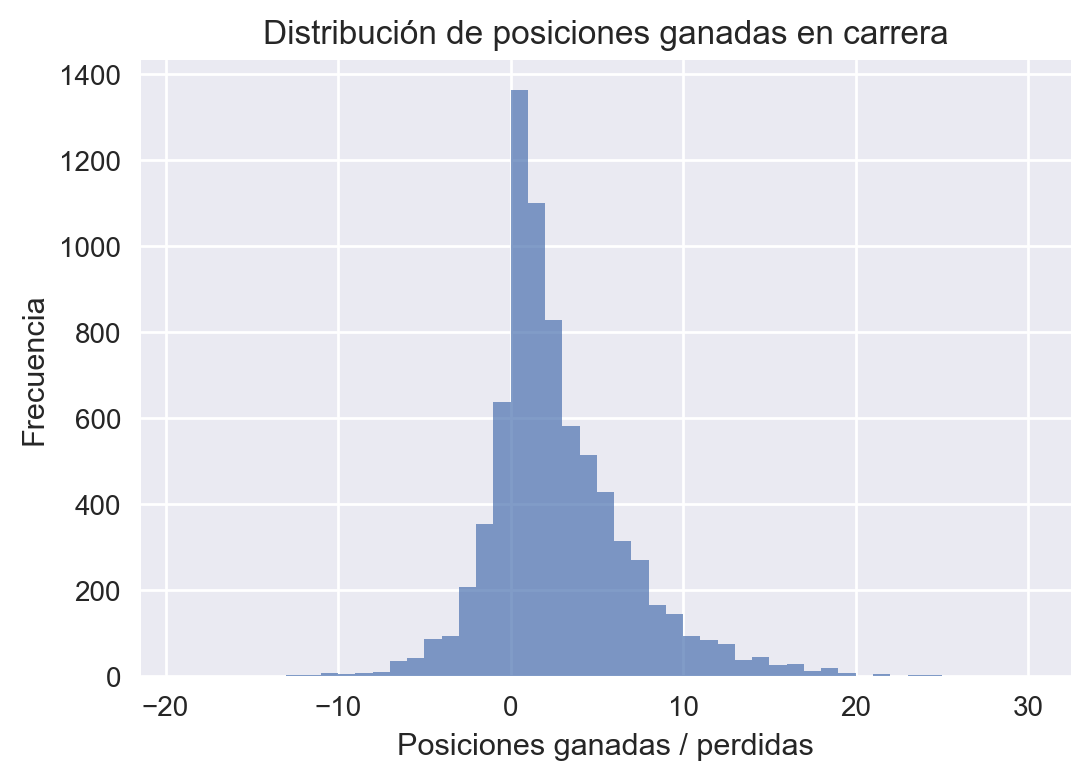

In [20]:
# Se filtran únicamente los pilotos que finalizaron la carrera
df_finished = df_results[df_results['statusId'] == 1].copy()

# Se calcula la variación de posiciones
df_finished['positions_gained'] = df_finished['grid'] - df_finished['position']

# Se extrae la serie
s_progreso = df_finished['positions_gained']

# Se definen los intervalos incluyendo el máximo
intervalos = np.arange(s_progreso.min(), s_progreso.max() + 1, 1)

# Se crea la figura
plt.figure(figsize=(6,4))

plt.hist(s_progreso, bins=intervalos, alpha=0.7)

plt.title('Distribución de posiciones ganadas en carrera')
plt.xlabel('Posiciones ganadas / perdidas')
plt.ylabel('Frecuencia')

plt.show()

<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

---

La distribución muestra una concentración significativa en torno a cero, lo que sugiere que la mayoría de pilotos tienden a finalizar en posiciones cercanas a su posición de salida. 

Esto indica que, aunque existen variaciones relevantes, la clasificación sigue siendo un determinante importante del resultado final.

In [21]:
# Estadísticos descriptivos de la variación de posiciones

mean_gain = s_progreso.mean()
median_gain = s_progreso.median()
std_gain = s_progreso.std()
quantiles = s_progreso.quantile([0.25, 0.75])

print("=== Statistical Summary: Positions Gained ===\n")

print(f"Mean: {mean_gain:.2f}")
print(f"Median: {median_gain:.2f}")
print(f"Standard deviation: {std_gain:.2f}")
print(f"25th percentile: {quantiles.loc[0.25]:.2f}")
print(f"75th percentile: {quantiles.loc[0.75]:.2f}")

=== Statistical Summary: Positions Gained ===

Mean: 2.24
Median: 1.00
Standard deviation: 4.20
25th percentile: 0.00
75th percentile: 4.00


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

### Interpretación estadística

La media cercana a cero indica que, en términos agregados, no existe una tendencia fuerte a ganar o perder posiciones durante la carrera.

La mediana próxima a cero refuerza la idea de que el resultado más frecuente es finalizar en posiciones similares a las de salida.

El rango intercuartílico muestra que el 50% central de los pilotos gana o pierde un número limitado de posiciones, lo que sugiere que grandes remontadas o caídas significativas son relativamente menos frecuentes.

En conjunto, los resultados cuantitativos respaldan la hipótesis de que la posición de salida constituye un determinante estructural del resultado final, aunque con margen para variaciones estratégicas o incidentes en carrera.

### <i class="fa fa-bar-chart" aria-hidden="true"></i> Análisis comparativo: media de posiciones ganadas en carreras finalizadas

Con el objetivo de identificar a los pilotos con mayor capacidad media de progresión en carrera, se calcula el número de posiciones ganadas por piloto, considerando exclusivamente aquellas carreras que fueron finalizadas.

La métrica de progresión se define como:

    Positions Gained = Grid Position - Final Position

El análisis sigue los siguientes pasos metodológicos:

- Se calcula la variación de posiciones y se incorpora como nueva columna mediante `DataFrame.assign()`.
- Se filtran únicamente las carreras finalizadas (`statusId = 1`).
- Se agrupan los resultados por piloto (`driverId`).
- Se calcula la media de posiciones ganadas para cada piloto.
- Se seleccionan los cinco valores más elevados.
- Finalmente, el resultado se integra con `df_drivers` para incorporar nombre, apellidos y nacionalidad.

Esta métrica permite evaluar la capacidad promedio de remontada en condiciones reales de carrera, controlando el sesgo introducido por abandonos. A diferencia del análisis agregado anterior, aquí se identifican perfiles individuales con mayor eficiencia estratégica y competitiva en pista.

In [22]:
df_pos_ganadas = (df_results.assign(pos_ganadas=lambda df: df.grid - df.position)[df_results['statusId']==1]
                        .groupby('driverId')[['pos_ganadas']]
                        .mean()
                        .nlargest(5, 'pos_ganadas')
                        .rename(columns={'pos_ganadas': 'pos_ganadas (media)'})
                 )
df_pos_ganadas

,pos_ganadas (media)
driverId,
659,24.0
734,24.0
560,23.0
591,23.0
613,21.0


In [23]:
# Se fusiona el dataframe que incluye las posiciones ganadas con el dataframe de los pilotos
pd.merge(df_pos_ganadas, df_drivers, left_index=True, right_index=True)[['forename','surname','pos_ganadas (media)']].sort_values(by=['pos_ganadas (media)'], ascending=False)

,forename,surname,pos_ganadas (media)
driverId,,,
659,Jerry,Hoyt,24.0
734,Bobby,Ball,24.0
560,Bill,Cheesbourg,23.0
591,George,Amick,23.0
613,Marshall,Teague,21.0


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div><br>



¿Cuantas carreras ha disputado y concluido el piloto más destacado en este aspecto?

In [24]:
print('El piloto más destacado en este aspecto ha disputado',len(df_results[df_results['driverId']==659]), 'carreras, de las que sólo concluyó',
      len(df_results[(df_results['driverId']==659) & (df_results['statusId']==1)]))

El piloto más destacado en este aspecto ha disputado 5 carreras, de las que sólo concluyó 1


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>


### <i class="fa fa-balance-scale" aria-hidden="true"></i> Corrección de sesgo por tamaño muestral</font>

El análisis anterior puede verse afectado por un sesgo derivado del tamaño de muestra: algunos pilotos con muy pocas participaciones pueden presentar una media elevada de posiciones ganadas simplemente por variabilidad estadística y no necesariamente por rendimiento estructural.

Para mitigar este efecto, se restringe el análisis a aquellos pilotos que hayan finalizado al menos 50 carreras. De este modo, se garantiza que la media calculada se sustente en un volumen suficiente de observaciones, aumentando la robustez del indicador.

Metodológicamente, el procedimiento consiste en:

- Calcular la variación de posiciones e incorporarla como nueva columna.
- Filtrar únicamente las carreras finalizadas (`statusId = 1`).
- Agrupar los datos por piloto.
- Aplicar un filtro que conserve exclusivamente aquellos grupos con al menos 50 observaciones.
- Calcular la media de posiciones ganadas para cada piloto.
- Seleccionar los cinco valores más elevados.
- Integrar el resultado con `df_drivers` para incorporar la información descriptiva correspondiente.

Esta restricción permite obtener un ranking más representativo del rendimiento medio en carrera, evitando que resultados extremos derivados de muestras pequeñas distorsionen la interpretación.

In [25]:
# Se hace un filtrado al DataFrame, tomando en cuenta únicamente los pilotos con más de 50 carreras disputadas
df_pos_ganadas_filtrado = (
    df_results
        .assign(pos_ganadas=lambda df: df['grid'] - df['position'])
        .query("statusId == 1")
        .groupby('driverId')
        .filter(lambda x: len(x) >= 50)
)

df_pos_ganadas_filtrado.head()

,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,pos_ganadas
resultId,,,,,,,,,,,,,,,,,,
1,18,1,1,22.0,1,1.0,1,1,10.0,58,1:34:50.616,5690616.0,39.0,2.0,1:27.452,218.300,1,0.0
2,18,2,2,3.0,5,2.0,2,2,8.0,58,+5.478,5696094.0,41.0,3.0,1:27.739,217.586,1,3.0
3,18,3,3,7.0,7,3.0,3,3,6.0,58,+8.163,5698779.0,41.0,5.0,1:28.090,216.719,1,4.0
4,18,4,4,5.0,11,4.0,4,4,5.0,58,+17.181,5707797.0,58.0,7.0,1:28.603,215.464,1,7.0
23,19,8,6,1.0,2,1.0,1,1,10.0,56,1:31:18.555,5478555.0,37.0,2.0,1:35.405,209.158,1,1.0


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

In [26]:
top5 = (
    df_pos_ganadas_filtrado
        .groupby('driverId')['pos_ganadas']
        .mean()
        .sort_values(ascending=False)
        .head(5)
        .to_frame(name='avg_positions_gained')
)

top5

,avg_positions_gained
driverId,
55,3.229508
56,2.862745
21,2.807229
182,2.794118
2,2.500000


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

In [27]:
# Del dataframe resultante se extrae la serie con los 5 pilotos con mejor media de posiciones ganadas
s_pos_ganadas_filtrado = (
    df_pos_ganadas_filtrado
        .groupby('driverId')['pos_ganadas']
        .mean()
        .nlargest(5)
        .rename('avg_positions_gained')
)

# Se fusiona la serie con el dataframe de los pilotos, seleccionando las columnas requeridas
top5 = (
    s_pos_ganadas_filtrado
        .to_frame()
        .join(df_drivers[['forename', 'surname', 'nationality']])
        .sort_values(by='avg_positions_gained', ascending=False)
        .round(2)
)

top5

,avg_positions_gained,forename,surname,nationality
driverId,,,,
55,3.23,Jean,Alesi,French
56,2.86,Eddie,Irvine,British
21,2.81,Giancarlo,Fisichella,Italian
182,2.79,Niki,Lauda,Austrian
2,2.50,Nick,Heidfeld,German


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

In [28]:
print('El piloto más destacado en el progreso en carrera ha disputado',len(df_results[df_results['driverId']==55]),
      'carreras, de las que concluyó ',
      len(df_results[(df_results['driverId']==55) & (df_results['statusId']==1)]))

El piloto más destacado en el progreso en carrera ha disputado 202 carreras, de las que concluyó  61


<div align="right">
<a href="#indice"><font size=5><i class="fa fa-arrow-circle-up" aria-hidden="true"></i></font></a>
</div>

---
<a id="section4"></a>
## 4. Rendimiento de Fernando Alonso
<br>

En esta sección se analiza el rendimiento del piloto español **Fernando Alonso** a lo largo de su trayectoria en Fórmula 1. El objetivo es estudiar distintos indicadores de desempeño en carrera —como posiciones finales, resultados destacados o evolución a lo largo del tiempo— para obtener una visión cuantitativa de su rendimiento dentro de la competición.

A partir de los datos disponibles, se explorarán diferentes métricas y visualizaciones que permitirán identificar patrones en sus resultados, evaluar su consistencia y contextualizar su desempeño dentro del conjunto de pilotos del campeonato.


---

### <i class="fa fa-user" aria-hidden="true"></i> Análisis de resultados</font>

Cuando el análisis se centra en un subconjunto específico de observaciones, resulta metodológicamente conveniente almacenar el resultado de la selección condicional en una estructura independiente. Esto facilita cálculos posteriores y mejora la claridad del flujo analítico.

En este caso, se extraen todos los resultados correspondientes a Fernando Alonso y se almacenan en un *DataFrame* denominado `df_results_alo`.

A partir de este subconjunto:

- Se contabilizan todas las participaciones del piloto.
- Se identifican las carreras finalizadas, considerando que el valor `statusId = 1` indica que el piloto concluyó la prueba.
- Se calcula el número total de carreras terminadas.

Este análisis permite diferenciar entre participación y finalización efectiva, una distinción relevante en estudios de consistencia y fiabilidad deportiva. El número de carreras completadas constituye un indicador complementario al de victorias o podios, ya que refleja estabilidad competitiva a lo largo del tiempo.

In [29]:
df_results_alo = df_results[(df_results['driverId'] == alonso_id)]
print('Número de carreras disputadas: ', len(df_results_alo))

Número de carreras disputadas:  404


In [30]:
df_results_alo_finished = df_results[(df_results['driverId'] == alonso_id) & (df_results['statusId']==1)]
print('Número de carreras terminadas: ', len(df_results_alo_finished))

Número de carreras terminadas:  261


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>


### <i class="fa fa-trophy" aria-hidden="true"></i> Análisis de podios

La columna `position` del DataFrame `df_results` (y de su subconjunto `df_results_alo`) indica la posición final obtenida por el piloto en cada carrera.

Con el objetivo de evaluar el rendimiento competitivo de Fernando Alonso más allá de las victorias, se calcula el número total de podios obtenidos a lo largo de su trayectoria deportiva. Se consideran podio aquellas posiciones finales comprendidas entre la primera y la tercera (inclusive).

El procedimiento consiste en:

- Seleccionar, dentro de `df_results_alo`, las observaciones cuya posición final sea 1, 2 o 3.
- Calcular el número total de registros que cumplen esta condición.

El número de podios constituye un indicador clave de competitividad sostenida, ya que refleja no solo la capacidad de ganar carreras, sino también la consistencia del piloto para mantenerse en posiciones de máximo rendimiento.

Desde una perspectiva analítica, esta métrica permite complementar el análisis de victorias y aporta una visión más equilibrada del desempeño histórico del piloto.

In [31]:
print('Número de podios: ', len(df_results_alo[df_results_alo['position']<=3]))

Número de podios:  106


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

### <i class="fa fa-line-chart" aria-hidden="true"></i> Perfil estadístico de rendimiento

Con el objetivo de construir una visión cuantitativa más completa del rendimiento deportivo de Fernando Alonso, se incorporan métricas relativas que permiten contextualizar los valores absolutos previamente calculados.

A partir del subconjunto `df_results_alo`, se definen los siguientes indicadores:

- **Carreras disputadas**: número total de participaciones.
- **Carreras finalizadas**: número de pruebas con `statusId = 1`.
- **Podios**: número de resultados con posición final 1, 2 o 3.
- **Victorias**: número de posiciones finales igual a 1.

A partir de estas magnitudes se calculan tres métricas clave:

- **Tasa de finalización**  
  Carreras finalizadas / Carreras disputadas

In [32]:
finish_rate_alo = len(df_results_alo_finished) / len(df_results_alo)

print(f"Tasa de finalización de Fernando Alonso: {finish_rate_alo:.2%}")

Tasa de finalización de Fernando Alonso: 64.60%


- **Tasa de podios**  
  Podios conseguidos / Carreras disputadas


In [33]:
podios_alo = len(df_results_alo_finished[df_results_alo_finished['position']<=3])
podios_rate_alo = podios_alo / len(df_results_alo)

print(f"Tasa de podios de Fernando Alonso: {podios_rate_alo:.2%}")

Tasa de podios de Fernando Alonso: 26.24%


- **Tasa de victorias**  
  Victorias conseguidas / Carreras disputadas

In [34]:
wins_alo = len(df_results_alo_finished[df_results_alo_finished['position']==1])
wins_rate_alo = wins_alo / len(df_results_alo)

print(f"Tasa de victorias de Fernando Alonso: {wins_rate_alo:.2%}")

Tasa de victorias de Fernando Alonso: 7.92%


Estas métricas permiten evaluar:

- La **fiabilidad competitiva** (capacidad de terminar carreras).
- La **consistencia en posiciones de élite** (frecuencia de podios).
- La **efectividad máxima** (capacidad de convertir participaciones en victorias).

El uso de tasas relativas facilita la comparación entre pilotos de distintas generaciones o con diferente número de participaciones, evitando sesgos derivados del volumen total de carreras disputadas.

In [35]:
print("=== Performance Summary: Fernando Alonso ===\n")

print(f"Total races: {len(df_results_alo)}")
print(f"Finished races: {len(df_results_alo_finished)} ({finish_rate_alo:.2%})")
print(f"Podiums: {podios_alo} ({podios_rate_alo:.2%})")
print(f"Wins: {wins_alo} ({wins_rate_alo:.2%})")

=== Performance Summary: Fernando Alonso ===

Total races: 404
Finished races: 261 (64.60%)
Podiums: 106 (26.24%)
Wins: 32 (7.92%)


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>


### <font size=3> <i class="fa fa-th-large" aria-hidden="true"></i> Análisis de posiciones de salida en primera y segunda línea</font>

Con el objetivo de evaluar el rendimiento de Fernando Alonso en sesiones de clasificación desde una perspectiva estratégica, se analiza el número de ocasiones en las que inició la carrera desde las dos primeras líneas de parrilla.

En términos reglamentarios, las posiciones comprendidas entre la primera y la cuarta representan la primera y segunda línea de salida, lo que suele otorgar una ventaja competitiva significativa en el desarrollo inicial de la carrera.

El análisis consiste en:

- Seleccionar, dentro de `df_results_alo`, aquellas participaciones cuya posición de salida (`grid`) se encuentre entre 1 y 4.
- Calcular el número total de registros que cumplen esta condición.

Este indicador permite medir la frecuencia con la que el piloto ha partido desde posiciones estratégicamente favorables, complementando el análisis de *pole positions* y ofreciendo una visión más amplia del rendimiento en clasificación.

In [36]:
primeras_lineas_alo = len(df_results_alo[df_results_alo['grid']<=4])
print('Número de veces que salió desde primera o segunda línea: ', primeras_lineas_alo)

Número de veces que salió desde primera o segunda línea:  102


- **Tasa de primeras y segundas líneas en la parrilla de salida**  
  nº carreras desde 2 primeras líneas / Carreras disputadas

In [37]:
primeras_lineas_rate_alo = primeras_lineas_alo / len(df_results_alo)

print(f"Tasa de primeras líneas de Fernando Alonso: {primeras_lineas_rate_alo:.2%}")

Tasa de primeras líneas de Fernando Alonso: 25.25%


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>


<div align="right">
<a href="#indice"><font size=5><i class="fa fa-arrow-circle-up" aria-hidden="true"></i></font></a>
</div>

---

<a id="section5"></a>
## 5. Escuderías</font>
<br>

### <i class="fa fa-industry" aria-hidden="true"></i> Integración de datos de escuderías

Con el objetivo de incorporar la información relativa a los equipos participantes en el campeonato, se procede a cargar el archivo `data/constructors.csv`, que contiene los datos descriptivos de las escuderías.

El conjunto de datos se almacena en un *DataFrame* denominado `df_constructors`, utilizando la primera columna del archivo como índice único de cada registro.

Esta estructuración permite mantener la coherencia del modelo de datos relacional del proyecto, facilitando la posterior integración de la información de equipos con los resultados de carrera y los datos de los pilotos dentro del flujo analítico.

In [38]:
df_constructors = pd.read_csv('./data/constructors.csv', index_col=0)
df_constructors.head()

,constructorRef,name,nationality,url
constructorId,,,,
1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>


### <i class="fa fa-flag-checkered" aria-hidden="true"></i> Constructores con mayor número de victorias históricas

Se identifican los cinco constructores que han acumulado un mayor número de victorias a lo largo de la historia de la competición, mostrando su nombre y nacionalidad.

Para ello, se consideran exclusivamente aquellos resultados en los que la posición final del equipo corresponde a la primera posición, que representa la victoria en la carrera.

El procedimiento analítico consiste en:

- Filtrar el DataFrame de resultados para seleccionar únicamente las victorias de escudería.
- Agrupar los registros por identificador de constructor (`constructorId`).
- Calcular el número total de victorias por equipo.
- Seleccionar los cinco valores más altos del ranking.
- Integrar el resultado con `df_constructors` para recuperar la información descriptiva.

Este análisis permite evaluar el dominio histórico de determinadas escuderías dentro del campeonato, proporcionando una visión agregada del rendimiento competitivo a nivel organizacional.

In [39]:
df_wins_escuderias = df_results[df_results['position']==1].groupby(['constructorId']).size().nlargest(5).to_frame('wins')
pd.merge(df_constructors, df_wins_escuderias, left_index=True, right_index=True)[['name', 'nationality', 'wins']].sort_values(by=['wins'], ascending=False)

,name,nationality,wins
constructorId,,,
6,Ferrari,Italian,249
1,McLaren,British,185
131,Mercedes,German,129
9,Red Bull,Austrian,122
3,Williams,British,114


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

### Análisis de puntos obtenidos por Fernando Alonso con cada escudería con la que compitió

Se analizan los puntos obtenidos por Fernando Alonso con cada escudería a lo largo de su trayectoria deportiva.

Para ello, se seleccionan las participaciones del piloto y se agregan los puntos obtenidos en cada combinación piloto–constructor, permitiendo evaluar el rendimiento competitivo asociado a cada equipo.

El procedimiento analítico consiste en:

- Filtrar los resultados correspondientes al piloto.
- Agrupar los datos por identificador de constructor (`constructorId`).
- Sumar los puntos obtenidos en cada grupo.
- Integrar la información con el DataFrame `df_constructors` para recuperar el nombre y la nacionalidad del equipo.

Este análisis permite identificar la contribución de cada escudería al total de puntos acumulados por el piloto, ofreciendo una perspectiva del rendimiento competitivo condicionado por el equipo técnico.

In [40]:
df_puntos_alo = df_results_alo.groupby('constructorId')[['points']].agg(sum)
pd.merge(df_constructors, df_puntos_alo, left_index=True, right_index=True)[['name', 'nationality', 'points']].sort_values(by=['points'], ascending=False)

,name,nationality,points
constructorId,,,
6,Ferrari,Italian,1190.0
4,Renault,French,468.0
117,Aston Martin,British,268.0
1,McLaren,British,241.0
214,Alpine F1 Team,French,162.0
18,Minardi,Italian,0.0


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

<div align="right">
<a href="#indice"><font size=5><i class="fa fa-arrow-circle-up" aria-hidden="true"></i></font></a>
</div>

---

<a id="section6"></a>
## 6. Circuitos
<br>

### <i class="fa fa-map-marker-alt" aria-hidden="true"></i> Integración del dataset de circuitos

El archivo `data/circuits.csv` contiene información descriptiva de los circuitos en los que se han celebrado carreras del campeonato.

Con el objetivo de incorporar esta dimensión geográfica dentro del modelo de datos, se procede a cargar el archivo en un *DataFrame* denominado `df_circuits`, utilizando `circuitId` como índice único de cada registro.

Esta estructuración facilita la posterior integración del dataset de circuitos con la información de resultados de carrera y otros conjuntos de datos del proyecto, permitiendo desarrollar análisis espaciales y contextuales sobre el campeonato.

In [41]:
df_circuits = pd.read_csv('./data/circuits.csv', index_col=0)
df_circuits.head()

,circuitRef,name,location,country,lat,lng,alt,url
circuitId,,,,,,,,
1,albert_park,Albert Park Grand Prix Circuit,Melbourne,Australia,-37.84970,144.96800,10,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
2,sepang,Sepang International Circuit,Kuala Lumpur,Malaysia,2.76083,101.73800,18,http://en.wikipedia.org/wiki/Sepang_Internatio...
3,bahrain,Bahrain International Circuit,Sakhir,Bahrain,26.03250,50.51060,7,http://en.wikipedia.org/wiki/Bahrain_Internati...
4,catalunya,Circuit de Barcelona-Catalunya,Montmeló,Spain,41.57000,2.26111,109,http://en.wikipedia.org/wiki/Circuit_de_Barcel...
5,istanbul,Istanbul Park,Istanbul,Turkey,40.95170,29.40500,130,http://en.wikipedia.org/wiki/Istanbul_Park


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>


### <i class="fa fa-rocket" aria-hidden="true"></i> Análisis de circuitos con mayor velocidad media en vuelta rápida

Con el objetivo de identificar los circuitos en los que se alcanzan mayores velocidades de rendimiento, se estudian las 100 vueltas más rápidas registradas en cada circuito, utilizando como criterio la variable `fastestLapSpeed`.

La métrica de velocidad característica del circuito se define como la media de los 100 valores más altos de velocidad de vuelta rápida disponibles para cada uno de ellos. Aunque este criterio puede ser refinado en futuros análisis, se adopta esta aproximación como simplificación metodológica.

El procedimiento analítico consiste en:

- Incorporar el identificador del circuito al DataFrame de resultados mediante la variable `circuitId` disponible en `df_races`.
- Integrar esta información con `df_results`, estableciendo explícitamente los índices del conjunto resultante.
- Agrupar los datos por circuito.
- Seleccionar las 100 mayores velocidades de vuelta rápida dentro de cada grupo.
- Calcular la media de dichas velocidades para obtener el indicador representativo del circuito.
- Ordenar los circuitos según este valor y seleccionar los cinco con mayor velocidad media.

Este análisis permite caracterizar los circuitos desde una perspectiva de velocidad de competición, proporcionando una medida agregada de la rapidez potencial de cada trazado dentro del campeonato.

In [42]:
df_velocidades = (
    df_results
        .merge(df_races.reset_index()[['raceId','circuitId']], on='raceId')
        .query("fastestLapSpeed.notna()")
        .groupby('circuitId')['fastestLapSpeed']
        .apply(lambda x: x.nlargest(100).mean())
        .nlargest(5)
        .to_frame(name='fastestLapSpeed_mean')
        .join(df_circuits[['name','country']])
        .reset_index()
        .sort_values('fastestLapSpeed_mean', ascending=False)
        .round(3)
)

df_velocidades

,circuitId,fastestLapSpeed_mean,name,country
0,14,250.744,Autodromo Nazionale di Monza,Italy
1,77,238.736,Jeddah Corniche Circuit,Saudi Arabia
2,9,235.304,Silverstone Circuit,UK
3,13,234.345,Circuit de Spa-Francorchamps,Belgium
4,80,230.022,Las Vegas Strip Street Circuit,United States


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

### <i class="fa fa-tachometer-alt" aria-hidden="true"></i> Circuitos más rápidos para Fernando Alonso

Se analiza la velocidad media en vuelta rápida alcanzada por Fernando Alonso en cada circuito a lo largo de su trayectoria deportiva, utilizando únicamente los datos contenidos en `df_results_alo`.

El procedimiento es análogo al análisis general de circuitos:

- Integrar el identificador del circuito (`circuitId`) con los resultados del piloto mediante el DataFrame `df_races`.
- Filtrar los registros con información de velocidad disponible (`fastestLapSpeed`).
- Agrupar los resultados por circuito y seleccionar las 100 mayores velocidades de vuelta rápida en cada grupo.
- Calcular la media de estas velocidades para cada circuito.
- Ordenar los circuitos según la media obtenida y mostrar los cinco con mayor velocidad.

Este análisis permite caracterizar los circuitos en los que el piloto ha alcanzado su mayor rendimiento en términos de velocidad de vuelta rápida, ofreciendo una visión individualizada de su desempeño histórico.

In [43]:
df_velocidades_alo = (
    df_results_alo
        .merge(df_races.reset_index()[['raceId','circuitId']])
        .query("fastestLapSpeed.notna()")
        .groupby('circuitId')['fastestLapSpeed']
        .apply(lambda x: x.nlargest(100).mean())
        .nlargest(5)
        .to_frame(name='fastestLapSpeed_mean')
        .join(df_circuits[['name','country']])
        .reset_index()
        .sort_values('fastestLapSpeed_mean', ascending=False)
        .round(3)
)

df_velocidades_alo

,circuitId,fastestLapSpeed_mean,name,country
0,14,243.239,Autodromo Nazionale di Monza,Italy
1,77,240.244,Jeddah Corniche Circuit,Saudi Arabia
2,80,231.198,Las Vegas Strip Street Circuit,United States
3,78,227.776,Losail International Circuit,Qatar
4,13,226.822,Circuit de Spa-Francorchamps,Belgium


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

### Circuitos donde obtuvo mejor rendimiento medio en carrera

Se analiza el rendimiento competitivo de :contentReference[oaicite:0]{index=0} en cada trazado histórico, evaluando la posición final media obtenida en cada circuito.

Dado que en Fórmula 1 una menor posición numérica implica un mejor resultado deportivo, los circuitos con menor valor promedio de `position` representan aquellos en los que el piloto mostró un desempeño más consistente y competitivo.

El análisis se realiza mediante los siguientes pasos:

- Integrar el identificador del circuito con los resultados del piloto.
- Filtrar los registros con información válida de posición final.
- Agrupar los datos por circuito y calcular la posición media obtenida.
- Seleccionar los circuitos con mejor rendimiento promedio (menor valor medio de posición).

In [44]:
df_best_circuits_alo = (
    df_results_alo
        .merge(df_races.reset_index()[['raceId','circuitId']])
        .query("position.notna()")
        .groupby('circuitId')['position']
        .mean()
        .nsmallest(5)
        .to_frame(name='avg_position')
        .join(df_circuits[['name','country']])
        .reset_index()
        .sort_values('avg_position')
        .round(3)
)

df_best_circuits_alo

,circuitId,avg_position,name,country
0,16,1.000,Fuji Speedway,Japan
1,19,3.500,Indianapolis Motor Speedway,USA
2,35,3.750,Korean International Circuit,Korea
3,12,4.250,Valencia Street Circuit,Spain
4,20,4.444,Nürburgring,Germany


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

### Visualización geográfica de los circuitos con Folium</font>

Se analiza la distribución geográfica de los circuitos mediante visualización interactiva con la librería `folium`.

Este análisis permite:

- Explorar la distribución geográfica de los circuitos históricos.  
- Identificar patrones regionales de los trazados del campeonato.  
- Integrar información contextual (país, nombre del circuito) directamente sobre la visualización.

In [45]:
import folium

# Diferentes mapas

# tiles = 'Stamen Toner'
tiles = 'OpenStreetMap'

europe_figure = folium.Figure(width=800, height=600)

# Se parte de Le Mans en Francia, ya que se encuentra en la parte central del mapa europeo
europe_map = folium.Map(location=[47.9500, 0.224231], tiles=tiles, zoom_start=5).add_to(europe_figure)

for name,circuit in df_circuits.iterrows():
    folium.Marker([circuit['lat'], circuit['lng']], popup=circuit['name']).add_to(europe_map)
    
europe_figure

<div align="right">
<a href="#indice"><font size=5><i class="fa fa-arrow-circle-up" aria-hidden="true"></i></font></a>
</div>

---

<a id="section7"></a>
## 7. Comparativa de rendimiento: Alonso vs rivales</font>
<br>

Se valoran los resultados de `Fernando Alonso` con respecto a sus rivales, es decir, con respecto a los pilotos que compitieron en las mismas carreras que él.

### Análisis de rivales directos en carrera

Con el objetivo de evaluar el rendimiento competitivo de Fernando ALonso, se identifican los pilotos que participaron en las mismas carreras que él, considerando únicamente los eventos previamente almacenados en `df_results_alo`.

El análisis se basa en la extracción de todos los registros correspondientes a las carreras en las que el piloto estuvo presente, excluyendo sus propias participaciones. De esta manera, se construye un subconjunto de datos que representa el entorno competitivo directo del piloto en cada prueba.

Este procedimiento permite caracterizar el nivel de oposición enfrentado durante su trayectoria deportiva, facilitando el estudio posterior de frecuencias de enfrentamiento y comparaciones de rendimiento entre rivales.

In [46]:
s_rivales_alo = df_results[(df_results['raceId'].isin(df_results_alo['raceId'])) & (df_results['driverId'] != alonso_id)]['driverId']
df_rivales_alo = df_drivers[df_drivers.index.isin(s_rivales_alo)]
df_rivales_alo.head()

,driverRef,number,code,forename,surname,dob,nationality,url
driverId,,,,,,,,
1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
5,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen
6,nakajima,NaN,NAK,Kazuki,Nakajima,1985-01-11,Japanese,http://en.wikipedia.org/wiki/Kazuki_Nakajima


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

### Análisis de los rivales más frecuentes

Se identifican los 10 pilotos contra los que Fernando Alonso ha competido en mayor número de ocasiones a lo largo de su trayectoria deportiva, con el objetivo de caracterizar el entorno competitivo más recurrente del piloto.

El análisis se basa en la construcción de un ranking de enfrentamientos directos, obteniendo primero el número de coincidencias entre carreras compartidas y pilotos rivales. Posteriormente:

- Se agrupan los resultados por identificador de piloto rival.
- Se calcula la frecuencia de enfrentamientos para cada grupo.
- Se seleccionan los 10 rivales con mayor número de coincidencias competitivas.
- Se integran los identificadores resultantes con el DataFrame `df_drivers` para recuperar la información descriptiva de cada piloto.

El resultado se almacena en el DataFrame `df_fa_vs`, que contiene los rivales más frecuentes junto con sus atributos identificativos.

In [47]:
df_fa_vs = (
    df_results
        .query("raceId in @df_results_alo.raceId and driverId != @alonso_id")
        .groupby('driverId')
        .size()
        .nlargest(10)
        .to_frame(name='n_races_vs_alonso')
        .join(df_drivers[['forename','surname','nationality']])
        .reset_index()
        .sort_values('n_races_vs_alonso', ascending=False)
)

df_fa_vs

,driverId,n_races_vs_alonso,forename,surname,nationality
0,1,316,Lewis,Hamilton,British
1,8,294,Kimi,Räikkönen,Finnish
2,18,272,Jenson,Button,British
3,20,259,Sebastian,Vettel,German
4,13,252,Felipe,Massa,Brazilian
5,815,244,Sergio,Pérez,Mexican
6,817,216,Daniel,Ricciardo,Australian
7,822,206,Valtteri,Bottas,Finnish
8,3,204,Nico,Rosberg,German
9,807,203,Nico,Hülkenberg,German


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

---

El siguiente análisis presenta una evaluación comparativa del desempeño de Fernando Alonso frente a los pilotos con los que ha competido directamente a lo largo de su trayectoria deportiva.

Este estudio tiene como objetivo sintetizar el balance competitivo del piloto, considerando las interacciones deportivas con sus rivales y las métricas de enfrentamiento previamente calculadas.

### <i class="fa fa-chart-line" aria-hidden="true"></i> Balance competitivo frente a rivales

El objetivo de este análisis es construir una matriz de resultados competitivos que permita comparar el desempeño de Fernando Alonso frente al resto de participantes en las carreras en las que ha participado durante su trayectoria deportiva.

Para ello, se genera una tabla en la que cada fila representa una carrera finalizada por el piloto, cada columna corresponde a un conductor que participó en dicha prueba, y el valor almacenado indica la posición final obtenida por cada piloto.

El resultado se almacena en el DataFrame `df_fa_vs_other`, el cual se construye mediante un proceso de transformación que incluye:

- Filtrado de los resultados que cumplen simultáneamente que el piloto finalizó la carrera y que el evento pertenece al conjunto de carreras disputadas por Alonso.
- Organización de los datos mediante un índice jerárquico.
- Extracción de la variable `position`.
- Reestructuración del conjunto de datos utilizando la operación `unstack()` para generar la matriz competitiva.

Esta estructura permite analizar el rendimiento relativo entre pilotos dentro de un mismo evento deportivo, facilitando comparaciones directas de desempeño en carrera.

In [48]:
df_fa_vs_other = df_results[(df_results['raceId'].isin(df_results_alo['raceId'])) & (df_results['statusId']==1)].set_index(['raceId', 'driverId'])['position'].unstack()

df_fa_vs_other

driverId,1,2,3,4,5,6,7,8,9,10,...,852,853,854,855,856,857,858,859,860,861
raceId,,,,,,,,,,,,,,,,,,,,,
1,NaN,10.0,6.0,5.0,NaN,NaN,8.0,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,7.0,2.0,8.0,NaN,NaN,NaN,10.0,NaN,NaN,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,6.0,12.0,NaN,9.0,5.0,NaN,11.0,10.0,13.0,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4.0,NaN,9.0,8.0,12.0,NaN,13.0,6.0,NaN,7.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,7.0,8.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1140,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,8.0,NaN,NaN,NaN,NaN
1141,10.0,NaN,NaN,14.0,NaN,NaN,NaN,NaN,NaN,NaN,...,7.0,NaN,NaN,15.0,NaN,8.0,NaN,9.0,12.0,NaN
1142,2.0,NaN,NaN,11.0,NaN,NaN,NaN,NaN,NaN,NaN,...,9.0,NaN,NaN,13.0,NaN,7.0,NaN,16.0,NaN,14.0


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

El objetivo de este análisis es identificar los 10 pilotos a los que Fernando ALonso ha derrotado en mayor número de ocasiones dentro de las carreras en las que ha participado a lo largo de su trayectoria deportiva.

Partiendo del DataFrame `df_fa_vs_other`, se construye un análisis comparativo que permite evaluar, para cada carrera, si la posición obtenida por Alonso es mejor que la de los demás pilotos que participaron en el mismo evento.

Metodológicamente, el procedimiento consiste en:

- Generar una estructura intermedia que evalúe, de forma fila a fila, si la posición de cada piloto rival es inferior a la posición del piloto de referencia (columna 4 de la matriz competitiva).
- Aplicar una operación `DataFrame.apply()` sobre las filas para construir el indicador de victoria relativa.
- Agregar los resultados por piloto sumando el número total de ocasiones en las que Alonso obtuvo mejor posición.
- Seleccionar los 10 valores más elevados del ranking.
- Integrar la información resultante con el DataFrame `df_drivers` para recuperar los atributos descriptivos de cada conductor.

Este análisis permite cuantificar el balance competitivo directo del piloto frente a sus oponentes más frecuentes dentro de las carreras finalizadas.

In [49]:
# Diccionario para guardar victorias en duelos
duel_wins = {}

# Carreras donde participó Alonso
races_alo = df_results_alo['raceId'].unique()

# Filtrar resultados de esas carreras
df_duels = df_results[
    df_results['raceId'].isin(races_alo) &
    (df_results['driverId'] != alonso_id)
]

# Unir resultados de Alonso con rivales por carrera
df_competition = df_results_alo[['raceId','position','statusId']].rename(
    columns={'position':'alo_position','statusId':'alo_status'}
)

df_duel_matrix = df_duels.merge(
    df_competition,
    on='raceId',
    how='inner'
)

# Evaluación de duelos
df_duel_matrix['alo_wins'] = df_duel_matrix.apply(
    lambda row: (
        # Alonso termina la carrera
        (row['alo_status'] == 1 and
            (
                row['position'] < row['alo_position']
                or row['statusId'] != 1
            )
        )
        or
        # Alonso no termina la carrera
        (row['alo_status'] != 1 and row['statusId'] == 1 and False)
    ),
    axis=1
)

# Contar victorias contra cada rival
df_alo_beats_other = (
    df_duel_matrix[df_duel_matrix['alo_wins']]
        .groupby('driverId')
        .size()
        .nlargest(10)
        .to_frame('n_duels_won')
        .join(df_drivers[['forename','surname','nationality']])
)

# Convertir a entero seguro
df_alo_beats_other['n_duels_won'] = df_alo_beats_other['n_duels_won'].astype('Int64')

df_alo_beats_other.sort_values('n_duels_won', ascending=False)

,n_duels_won,forename,surname,nationality
driverId,,,,
1,140,Lewis,Hamilton,British
18,119,Jenson,Button,British
20,113,Sebastian,Vettel,German
8,111,Kimi,Räikkönen,Finnish
17,104,Mark,Webber,Australian
815,103,Sergio,Pérez,Mexican
15,98,Jarno,Trulli,Italian
13,94,Felipe,Massa,Brazilian
22,93,Rubens,Barrichello,Brazilian


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

El objetivo de este análisis es identificar los 10 pilotos que han derrotado con mayor frecuencia a Fernando Alonso dentro de las carreras que ambos han compartido.

Para ello, se evalúa el balance competitivo directo entre Alonso y sus rivales, considerando las siguientes reglas:

- Si Alonso finalizó la carrera, se compara su posición con la de cada rival.
- Si el rival obtuvo una mejor posición o Alonso no finalizó la carrera, se considera que el rival ganó el duelo.
- Se agregan las victorias de los rivales mediante conteo de enfrentamientos favorables.
- Finalmente, se seleccionan los 10 pilotos con mayor número de duelos ganados contra Alonso.

Este análisis permite evaluar la competitividad relativa del piloto dentro del conjunto de enfrentamientos históricos.

In [50]:
# Evaluación de duelos competitivos: rivales que han batido a :contentReference[oaicite:0]{index=0}

# Un rival gana el duelo si:
# - Alonso finalizó la carrera y el rival obtuvo mejor posición
# - O Alonso no finalizó y el rival sí terminó la carrera

df_duel_matrix['rival_wins'] = df_duel_matrix.apply(
    lambda row: (
        # Alonso termina la carrera
        (row['alo_status'] == 1 and row['statusId'] == 1 and row['position'] < row['alo_position'])
        or
        # Alonso no termina y el rival sí
        (row['alo_status'] != 1 and row['statusId'] == 1)
    ),
    axis=1
)

# Contar victorias de los rivales contra Alonso
df_rivals_beating_alo = (
    df_duel_matrix[df_duel_matrix['rival_wins']]
        .groupby('driverId')
        .size()
        .nlargest(10)
        .to_frame('n_duels_lost')
        .join(df_drivers[['forename','surname','nationality']])
)

# Convertir a entero seguro
df_rivals_beating_alo['n_duels_lost'] = df_rivals_beating_alo['n_duels_lost'].astype('Int64')

df_rivals_beating_alo.sort_values('n_duels_lost', ascending=False)

,n_duels_lost,forename,surname,nationality
driverId,,,,
1,206,Lewis,Hamilton,British
20,152,Sebastian,Vettel,German
8,136,Kimi,Räikkönen,Finnish
830,132,Max,Verstappen,Dutch
815,106,Sergio,Pérez,Mexican
822,94,Valtteri,Bottas,Finnish
817,84,Daniel,Ricciardo,Australian
832,81,Carlos,Sainz,Spanish
3,80,Nico,Rosberg,German


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

### Reglas de evaluación competitiva en carrera

En el presente análisis se consideran las interacciones deportivas entre pilotos dentro de una misma carrera con el objetivo de construir un balance competitivo directo.

Se define que un piloto rival ha batido a Fernando Alonso en una carrera cuando se cumple alguna de las siguientes condiciones:

- Si Alonso finalizó la carrera (`statusId = 1`), se compara la posición final obtenida por cada piloto.
- El rival se considera vencedor del duelo si obtuvo una posición final estrictamente mejor (menor valor numérico) que la de Alonso.

- Si Alonso no finalizó la carrera (`statusId ≠ 1`) y el rival sí concluyó la prueba, se considera que el rival ganó el enfrentamiento directo.

Por el contrario, se considera que Alonso ha ganado el duelo cuando:

- Finalizó la carrera y obtuvo mejor posición que el rival.
- El rival no finalizó la carrera mientras Alonso sí lo hizo.

Estas reglas permiten construir un indicador de rendimiento competitivo relativo dentro de cada evento deportivo, integrando tanto la dimensión de posición final como la de fiabilidad en la finalización de las pruebas.

<div align="right">
<a href="#indice"><font size=5><i class="fa fa-arrow-circle-up" aria-hidden="true"></i></font></a>
</div>

---

<a id="section8"></a>
## 8. Comparativa histórica: Alonso vs Hamilton (temporada 2007, McLaren)
<br>

El presente análisis explora la comparación competitiva entre ambos pilotos durante la temporada 2007, período en el que compartieron escudería..

El hecho de que ambos pilotos compitieran con un monoplaza equivalente proporciona un contexto particularmente interesante para evaluar el rendimiento individual, ya que permite aproximar un escenario de igualdad mecánica y concentrar la comparación en variables asociadas al desempeño del conductor y a la gestión estratégica de carrera.

Desde un punto de vista analítico, este estudio representa una oportunidad para evaluar el balance competitivo directo entre ambos pilotos dentro de un entorno controlado.



### <i class="fa fa-chart-bar" aria-hidden="true"></i> Análisis comparativo de rendimiento

Se procede a extraer la información relativa a Lewis Hamilton, identificado mediante el código de piloto `HAM`.

Los datos del piloto se almacenan en una *Serie* denominada `hamilton_data`, utilizando el método `DataFrame.squeeze()` para convertir el resultado de la selección condicional en una estructura unidimensional cuando la extracción produce un subconjunto de una sola fila.

Adicionalmente, el identificador numérico del piloto se almacena en la variable `hamilton_id`, accediendo al atributo `name` de la Serie resultante para obtener el valor correspondiente al índice del registro seleccionado.

Esta operación facilita el tratamiento posterior de la información dentro del flujo analítico del proyecto.

In [51]:
hamilton_data = df_drivers[df_drivers['code']=='HAM'].squeeze()
hamilton_id = hamilton_data.name

El objetivo de este análisis es obtener el conjunto de carreras en las que participaron conjuntamente Fernando Alonso y Lewis Hamilton compartiendo escudería.

Para ello, se filtran los resultados correspondientes a las carreras de ambos pilotos, posteriormente se identifican los eventos en los que ambos coincidieron como compañeros de equipo y se almacenan los registros resultantes en el DataFrame `df_rac_ah`.

Este subconjunto de datos permite analizar el rendimiento comparativo de ambos pilotos dentro de un contexto técnico equivalente, eliminando el efecto de variaciones mecánicas entre diferentes constructores.

In [52]:
df_results_ham = df_results[(df_results['driverId'] == hamilton_id)]

df_rac_ah = pd.merge(df_results_alo, df_results_ham, how='inner', suffixes=['_alo', '_ham'], on=['raceId','constructorId'])

df_rac_ah

,raceId,driverId_alo,constructorId,number_alo,grid_alo,position_alo,positionText_alo,positionOrder_alo,points_alo,laps_alo,...,positionOrder_ham,points_ham,laps_ham,time_ham,milliseconds_ham,fastestLap_ham,rank_ham,fastestLapTime_ham,fastestLapSpeed_ham,statusId_ham
0,36,4,1,1.0,2,2.0,2,2,8.0,58,...,3,6.0,58,+18.595,5147365.0,20.0,3.0,1:26.351,221.083,1
1,37,4,1,1.0,2,1.0,1,1,10.0,56,...,2,8.0,56,+17.557,5552487.0,22.0,1.0,1:36.701,206.355,1
2,38,4,1,1.0,4,5.0,5,5,4.0,57,...,2,8.0,57,+2.360,5609875.0,18.0,2.0,1:34.270,206.674,1
3,39,4,1,1.0,2,3.0,3,3,6.0,65,...,2,8.0,65,+6.790,5503020.0,20.0,2.0,1:22.876,202.205,1
4,40,4,1,1.0,1,1.0,1,1,10.0,78,...,2,8.0,78,+4.095,6033424.0,28.0,2.0,1:15.372,159.528,1
5,41,4,1,1.0,2,7.0,7,7,2.0,70,...,1,10.0,70,1:44:11.292,6251292.0,37.0,2.0,1:16.494,205.239,1
6,42,4,1,1.0,2,2.0,2,2,8.0,73,...,1,10.0,73,1:31:09.965,5469965.0,20.0,2.0,1:13.222,206.101,1
7,43,4,1,1.0,10,7.0,7,7,2.0,70,...,3,6.0,70,+32.153,5486353.0,39.0,4.0,1:16.587,207.340,1
8,44,4,1,1.0,3,2.0,2,2,8.0,59,...,3,6.0,59,+39.373,4942447.0,11.0,4.0,1:21.675,226.600,1
9,45,4,1,1.0,2,1.0,1,1,10.0,60,...,9,0.0,59,NaN,NaN,29.0,3.0,1:33.401,198.421,11


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

Se construye una tabla comparativa de resultados competitivos entre Fernando Alonso y Lewis Hamilton, considerando exclusivamente las carreras contenidas en el DataFrame `df_rac_ah`.

El objetivo es generar una estructura donde cada fila represente una carrera disputada en conjunto y cada columna contenga la posición final obtenida por cada uno de los pilotos.

Para ello, se organiza el conjunto de datos mediante un índice jerárquico que incluya el identificador de carrera y el piloto, se extrae la variable de posición final y posteriormente se reestructura la información utilizando la operación `unstack()`. Esta transformación permite obtener una matriz competitiva directa entre ambos conductores.

A partir de esta tabla, se determina el número de duelos en los que cada piloto obtuvo mejor posición final, cuantificando el balance competitivo histórico entre ambos dentro del mismo contexto de equipo y evento deportivo.

In [53]:
df_rac_ah[['raceId','position_alo', 'position_ham']]

,raceId,position_alo,position_ham
0,36,2.0,3.0
1,37,1.0,2.0
2,38,5.0,2.0
3,39,3.0,2.0
4,40,1.0,2.0
5,41,7.0,1.0
6,42,2.0,1.0
7,43,7.0,3.0
8,44,2.0,3.0
9,45,1.0,9.0


<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

In [54]:
import numpy as np

# Definir función de comparación deportiva
def compare_positions(a, b):
    # Si ambos son NaN, no hay ganador
    if pd.isna(a) and pd.isna(b):
        return False
    
    # Si solo uno es NaN, el que tiene número gana
    if pd.isna(a):
        return False
    if pd.isna(b):
        return True
    
    # Si ambos son números, gana el menor (mejor posición)
    return a < b

# Aplicar comparación vectorizada
alo_beats_ham = df_rac_ah.apply(
    lambda row: compare_positions(row['position_alo'], row['position_ham']),
    axis=1
).sum()

ham_beats_alo = df_rac_ah.apply(
    lambda row: compare_positions(row['position_ham'], row['position_alo']),
    axis=1
).sum()

print(f"Alonso quedó por delante de Hamilton {int(alo_beats_ham)} veces.")
print(f"Hamilton quedó por delante de Alonso {int(ham_beats_alo)} veces.")

Alonso quedó por delante de Hamilton 10 veces.
Hamilton quedó por delante de Alonso 7 veces.


<div align="right">
<a href="#indice"><font size=5><i class="fa fa-arrow-circle-up" aria-hidden="true"></i></font></a>
</div>

---

<a id="section9"></a>
## 9. Conclusiones

El análisis realizado permite extraer varias conclusiones relevantes sobre el rendimiento de Fernando Alonso en Fórmula 1.

En primer lugar, el piloto presenta una elevada tasa de finalización de carreras, lo que refleja una gran consistencia competitiva. Además, el análisis de posiciones ganadas sugiere una notable capacidad para mejorar su posición durante las carreras.

Por otra parte, el estudio de enfrentamientos directos muestra que Alonso mantiene un balance positivo frente a numerosos rivales con los que ha compartido pista a lo largo de su trayectoria.

Finalmente, el análisis específico de su temporada junto a Lewis Hamilton en McLaren revela una rivalidad extremadamente equilibrada, lo que confirma el alto nivel competitivo de ambos pilotos.

En conjunto, los resultados sugieren que Fernando Alonso destaca no solo por su velocidad, sino también por su consistencia y capacidad estratégica durante las carreras.

### Trabajo futuro

Posibles extensiones del análisis:

- evolución temporal del rendimiento por temporada
- comparación con otros campeones del mundo
- análisis del impacto del constructor en el rendimiento
- modelado predictivo de resultados de carrera

<div><font size=3> <i class="fa fa-check-square-o" aria-hidden="true"></i></font></div>

---

<div align="right">
<a href="#indice"><font size=6 color="#00586D"><i class="fa fa-coffee" aria-hidden="true"></i></font></a>
</div>